In [1]:
pip install pandas numpy matplotlib seaborn openpyxl


  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached numpy-2.3.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl (10.7 MB)
Using cached numpy-2.3.4-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.6 MB/s  0:00:02 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached cycler-0.12.1-py3-none-any.whl 

In [2]:
# 单元格 1: 导入必要的库
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("✅ 所有必要的库已导入")

✅ 所有必要的库已导入


In [ ]:
# 单元格 2: 定义数据清洗类
class HKAccidentDataCleaner:
    def __init__(self, data_folder_path):
        self.data_folder = data_folder_path
        self.cleaned_data = {}
        
    def load_all_data(self):
        """加载所有数据文件"""
        data_files = {}
        for file in os.listdir(self.data_folder):
            if file.endswith(('.csv', '.xlsx')):
                file_path = os.path.join(self.data_folder, file)
                try:
                    if file.endswith('.csv'):
                        df = pd.read_csv(file_path)
                    else:
                        df = pd.read_excel(file_path)
                    data_files[file] = df
                    print(f"✅ 已加载: {file} (形状: {df.shape})")
                except Exception as e:
                    print(f"❌ 加载失败 {file}: {e}")
        return data_files
    
    def standardize_column_names(self, df):
        """标准化列名"""
        df.columns = (df.columns
                     .str.strip()
                     .str.lower()
                     .str.replace(' ', '_')
                     .str.replace('/', '_')
                     .str.replace('(', '')
                     .str.replace(')', '')
                     .str.replace('.', '')
                     .str.replace(':', ''))
        return df
    
    def handle_missing_values(self, df):
        """处理缺失值"""
        # 数值列用0填充
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        df[numeric_cols] = df[numeric_cols].fillna(0)
        
        # 分类列用'Unknown'填充
        categorical_cols = df.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            df[col] = df[col].fillna('Unknown')
            
        return df
    
    def standardize_age_groups(self, df):
        """标准化年龄分组"""
        if 'age' in df.columns:
            age_mapping = {
                'under 11': '0-10',
                '11-15': '11-15', 
                '16-20': '16-20',
                '21-25': '21-25',
                '26-30': '26-30',
                '31-35': '31-35',
                '36-40': '36-40',
                '41-45': '41-45',
                '46-50': '46-50',
                '51-55': '51-55',
                '56-60': '56-60',
                '61-65': '61-65',
                '66-70': '66-70',
                'over 70': '70+',
                'unknown': 'Unknown'
            }
            df['age'] = df['age'].str.lower().map(age_mapping).fillna(df['age'])
        return df
    
    def standardize_road_user_classes(self, df):
        """标准化道路使用者分类"""
        if 'class_of_road_user' in df.columns:
            mapping = {
                'driver (all)': 'Driver',
                'drivers (motor cyclist)': 'Motorcycle Driver',
                'driver (cyclist)': 'Cyclist',
                'pedestrian': 'Pedestrian',
                'passenger': 'Passenger',
                'unknown': 'Unknown'
            }
            df['class_of_road_user'] = df['class_of_road_user'].map(mapping).fillna(df['class_of_road_user'])
        return df
    
    def standardize_vehicle_classes(self, df):
        """标准化车辆分类"""
        if 'class_of_vehicle' in df.columns:
            mapping = {
                'motor cycle': 'Motorcycle',
                'private car': 'Private Car',
                'taxi': 'Taxi',
                'public light bus': 'Public Light Bus', 
                'public bus': 'Public Bus',
                'light goods vehicle': 'Light Goods Vehicle',
                'medium & heavy goods vehicles': 'Heavy Goods Vehicle',
                'bicycle': 'Bicycle',
                'others': 'Other Vehicles',
                'unknown': 'Unknown'
            }
            df['class_of_vehicle'] = df['class_of_vehicle'].map(mapping).fillna(df['class_of_vehicle'])
        return df
    
    def standardize_severity(self, df):
        """标准化严重程度分类"""
        severity_columns = [col for col in df.columns if 'severity' in col.lower()]
        
        for col in severity_columns:
            if df[col].dtype == 'object':
                mapping = {
                    'fatal': 'Fatal',
                    'serious': 'Serious', 
                    'slight': 'Slight',
                    'all': 'All',
                    'killed': 'Fatal',
                    'seriously injured': 'Serious',
                    'slightly injured': 'Slight'
                }
                df[col] = df[col].map(mapping).fillna(df[col])
                
        return df
    
    def clean_numeric_columns(self, df):
        """清理数值列"""
        # 移除数值列中的特殊字符并转换为数字
        numeric_patterns = ['no_', 'number_of', 'casualties', 'population', 'rate', 'involvements']
        
        for col in df.columns:
            if any(pattern in col.lower() for pattern in numeric_patterns) and df[col].dtype == 'object':
                # 移除逗号和其他非数字字符
                df[col] = (df[col].astype(str)
                          .str.replace(',', '')
                          .str.replace(' ', '')
                          .str.replace('N.A.', '0')
                          .str.replace('na', '0')
                          .str.replace('-', '0'))
                
                # 转换为数值，无法转换的设为NaN
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        return df
    
    def validate_data_consistency(self, df, df_name):
        """验证数据一致性"""
        print(f"\n🔍 验证数据: {df_name}")
        print(f"   形状: {df.shape}")
        print(f"   缺失值统计:")
        print(df.isnull().sum())
        
        # 检查数值列的合理性
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            print(f"   数值列范围:")
            for col in numeric_cols[:3]:  # 只显示前3个以免输出过长
                if df[col].notna().any():
                    print(f"     {col}: {df[col].min():.2f} - {df[col].max():.2f}")
    
    def process_dataset(self, df, df_name):
        """处理单个数据集"""
        print(f"\n🔄 处理: {df_name}")
        
        # 复制原始数据
        cleaned_df = df.copy()
        
        # 应用所有清洗步骤
        cleaned_df = self.standardize_column_names(cleaned_df)
        cleaned_df = self.handle_missing_values(cleaned_df)
        cleaned_df = self.standardize_age_groups(cleaned_df)
        cleaned_df = self.standardize_road_user_classes(cleaned_df)
        cleaned_df = self.standardize_vehicle_classes(cleaned_df)
        cleaned_df = self.standardize_severity(cleaned_df)
        cleaned_df = self.clean_numeric_columns(cleaned_df)
        
        # 验证结果
        self.validate_data_consistency(cleaned_df, df_name)
        
        return cleaned_df
    
    def clean_all_data(self):
        """清洗所有数据"""
        print("🚀 开始数据清洗过程...")
        
        # 加载数据
        raw_data = self.load_all_data()
        
        if not raw_data:
            print("❌ 没有找到数据文件！")
            return
        
        # 处理每个数据集
        for file_name, df in raw_data.items():
            base_name = os.path.splitext(file_name)[0]
            cleaned_df = self.process_dataset(df, base_name)
            self.cleaned_data[base_name] = cleaned_df
        
        print(f"\n✅ 数据清洗完成！共处理 {len(self.cleaned_data)} 个数据集")
        
    def save_cleaned_data(self, output_folder='cleaned_data'):
        """保存清洗后的数据"""
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        for name, df in self.cleaned_data.items():
            output_path = os.path.join(output_folder, f"{name}_cleaned.csv")
            df.to_csv(output_path, index=False, encoding='utf-8-sig')
            print(f"💾 已保存: {output_path}")
    
    def generate_cleaning_report(self):
        """生成清洗报告"""
        print("\n" + "="*50)
        print("📊 数据清洗报告")
        print("="*50)
        
        for name, df in self.cleaned_data.items():
            print(f"\n📁 数据集: {name}")
            print(f"   行数: {len(df)}")
            print(f"   列数: {len(df.columns)}")
            print(f"   数值列: {len(df.select_dtypes(include=[np.number]).columns)}")
            print(f"   分类列: {len(df.select_dtypes(include=['object']).columns)}")
            
            # 显示前几列的信息
            print(f"   列名示例: {list(df.columns[:5])}")

print("✅ HKAccidentDataCleaner 类定义完成")

✅ HKAccidentDataCleaner 类定义完成


In [6]:
# 单元格 3: 设置数据路径并初始化清洗器
# 请将下面的路径替换为您的实际数据文件夹路径
data_folder = "./Datasets/M1_RTAS/"  # 修改为您的数据文件夹路径

# 检查数据文件夹是否存在
if not os.path.exists(data_folder):
    display(Markdown("**⚠️ 警告: 数据文件夹不存在，请修改 `data_folder` 变量**"))
    print(f"当前数据文件夹路径: {data_folder}")
else:
    print(f"✅ 数据文件夹存在: {data_folder}")
    print("📁 文件夹内容:")
    for file in os.listdir(data_folder):
        print(f"   - {file}")

# 创建清洗器实例
cleaner = HKAccidentDataCleaner(data_folder)

✅ 数据文件夹存在: ./Datasets/M1_RTAS/
📁 文件夹内容:
   - f1.3_eng.csv
   - f2.7_eng.csv
   - f3.12_eng.csv
   - f2.14_eng.csv
   - f3.4_eng.csv
   - f1.11_eng.csv
   - f3.5_eng.csv
   - .DS_Store
   - f1.10_eng.csv
   - f1.2_eng.csv
   - f3.13_eng.csv
   - f2.6_eng.csv
   - f2.15_eng.csv
   - f1.9_eng.csv
   - f3.7_eng.csv
   - f1.12_eng.csv
   - f3.11_eng.csv
   - f2.4_eng.csv
   - f2.5_eng.csv
   - accident_stat_2023_dataspec_eng.pdf
   - f3.10_eng.csv
   - f1.1_eng.csv
   - f1.8_eng.csv
   - f3.6_eng.csv
   - f1.13_eng.csv
   - f3.3_eng.csv
   - f2.9_eng.csv
   - f2.13_eng.csv
   - f1.4_eng.csv
   - fa1_eng.csv
   - f2.12_eng.csv
   - f3.14_eng.csv
   - f2.1_eng.csv
   - f1.5_eng.csv
   - key_eng.csv
   - f3.2_eng.csv
   - f2.8_eng.csv
   - f2.10_eng.csv
   - f1.7_eng.csv
   - f3.9_eng.csv
   - f2.3_eng.csv
   - f1.14_eng.csv
   - f3.1_eng.csv
   - f2.11_eng.csv
   - f1.6_eng.csv
   - f3.8_eng.csv
   - f2.2_eng.csv


In [7]:
# 单元格 4: 执行数据清洗
display(Markdown("## 开始数据清洗过程"))

try:
    cleaner.clean_all_data()
    display(Markdown("### ✅ 数据清洗完成"))
except Exception as e:
    display(Markdown("### ❌ 数据清洗失败"))
    print(f"错误信息: {e}")

## 开始数据清洗过程

🚀 开始数据清洗过程...
✅ 已加载: f1.3_eng.csv (形状: (39, 13))
✅ 已加载: f2.7_eng.csv (形状: (20, 6))
✅ 已加载: f3.12_eng.csv (形状: (14, 10))
✅ 已加载: f2.14_eng.csv (形状: (22, 6))
✅ 已加载: f3.4_eng.csv (形状: (23, 7))
✅ 已加载: f1.11_eng.csv (形状: (20, 11))
✅ 已加载: f3.5_eng.csv (形状: (41, 8))
✅ 已加载: f1.10_eng.csv (形状: (20, 5))
✅ 已加载: f1.2_eng.csv (形状: (36, 13))
✅ 已加载: f3.13_eng.csv (形状: (13, 9))
✅ 已加载: f2.6_eng.csv (形状: (22, 5))
✅ 已加载: f2.15_eng.csv (形状: (4, 5))
✅ 已加载: f1.9_eng.csv (形状: (108, 5))
✅ 已加载: f3.7_eng.csv (形状: (11, 5))
✅ 已加载: f1.12_eng.csv (形状: (8, 5))
✅ 已加载: f3.11_eng.csv (形状: (6, 6))
✅ 已加载: f2.4_eng.csv (形状: (6, 5))
✅ 已加载: f2.5_eng.csv (形状: (51, 10))
✅ 已加载: f3.10_eng.csv (形状: (19, 8))
✅ 已加载: f1.1_eng.csv (形状: (39, 13))
✅ 已加载: f1.8_eng.csv (形状: (18, 8))
✅ 已加载: f3.6_eng.csv (形状: (19, 12))
✅ 已加载: f1.13_eng.csv (形状: (19, 4))
✅ 已加载: f3.3_eng.csv (形状: (19, 12))
✅ 已加载: f2.9_eng.csv (形状: (13, 5))
✅ 已加载: f2.13_eng.csv (形状: (20, 6))
✅ 已加载: f1.4_eng.csv (形状: (20, 11))
✅ 已加载: fa1_eng.csv (形状: (29, 3))
✅ 已加载: f2.12_eng.c

### ✅ 数据清洗完成

In [8]:
# 单元格 5: 保存清洗后的数据
display(Markdown("## 保存清洗后的数据"))

try:
    cleaner.save_cleaned_data()
    display(Markdown("### ✅ 数据保存完成"))
except Exception as e:
    display(Markdown("### ❌ 数据保存失败"))
    print(f"错误信息: {e}")

## 保存清洗后的数据

💾 已保存: cleaned_data/f1.3_eng_cleaned.csv
💾 已保存: cleaned_data/f2.7_eng_cleaned.csv
💾 已保存: cleaned_data/f3.12_eng_cleaned.csv
💾 已保存: cleaned_data/f2.14_eng_cleaned.csv
💾 已保存: cleaned_data/f3.4_eng_cleaned.csv
💾 已保存: cleaned_data/f1.11_eng_cleaned.csv
💾 已保存: cleaned_data/f3.5_eng_cleaned.csv
💾 已保存: cleaned_data/f1.10_eng_cleaned.csv
💾 已保存: cleaned_data/f1.2_eng_cleaned.csv
💾 已保存: cleaned_data/f3.13_eng_cleaned.csv
💾 已保存: cleaned_data/f2.6_eng_cleaned.csv
💾 已保存: cleaned_data/f2.15_eng_cleaned.csv
💾 已保存: cleaned_data/f1.9_eng_cleaned.csv
💾 已保存: cleaned_data/f3.7_eng_cleaned.csv
💾 已保存: cleaned_data/f1.12_eng_cleaned.csv
💾 已保存: cleaned_data/f3.11_eng_cleaned.csv
💾 已保存: cleaned_data/f2.4_eng_cleaned.csv
💾 已保存: cleaned_data/f2.5_eng_cleaned.csv
💾 已保存: cleaned_data/f3.10_eng_cleaned.csv
💾 已保存: cleaned_data/f1.1_eng_cleaned.csv
💾 已保存: cleaned_data/f1.8_eng_cleaned.csv
💾 已保存: cleaned_data/f3.6_eng_cleaned.csv
💾 已保存: cleaned_data/f1.13_eng_cleaned.csv
💾 已保存: cleaned_data/f3.3_eng_cleaned.csv
💾 已保存:

### ✅ 数据保存完成

In [9]:
# 单元格 6: 生成清洗报告
display(Markdown("## 数据清洗报告"))

cleaner.generate_cleaning_report()


## 数据清洗报告


📊 数据清洗报告

📁 数据集: f1.3_eng
   行数: 39
   列数: 13
   数值列: 11
   分类列: 2
   列名示例: ['age', 'item', '2013', '2014', '2015']

📁 数据集: f2.7_eng
   行数: 20
   列数: 6
   数值列: 4
   分类列: 2
   列名示例: ['type_of_accident_collision', 'severity', 'road_surface_condition_wet', 'road_surface_condition_dry', 'road_surface_condition_unknown']

📁 数据集: f3.12_eng
   行数: 14
   列数: 10
   数值列: 9
   分类列: 1
   列名示例: ['age', 'class_of_motor_vehicle_motor_cycle', 'class_of_motor_vehicle_private_car', 'class_of_motor_vehicle_taxi', 'class_of_motor_vehicle_public_light_bus']

📁 数据集: f2.14_eng
   行数: 22
   列数: 6
   数值列: 5
   分类列: 1
   列名示例: ['tunnel_area', 'severity_fatal', 'severity_serious', 'severity_slight', 'severity_all']

📁 数据集: f3.4_eng
   行数: 23
   列数: 7
   数值列: 6
   分类列: 1
   列名示例: ['class_of_vehicle', 'no_of_accidents', 'no_of_involvements', 'no_of_casualties_killed', 'no_of_casualties_seriously_injured']

📁 数据集: f1.11_eng
   行数: 20
   列数: 11
   数值列: 10
   分类列: 1
   列名示例: ['age', 'no_of_pedestrian_casualties_male

In [10]:
# 单元格 7: 预览清洗后的数据
display(Markdown("## 预览清洗后的数据"))

if cleaner.cleaned_data:
    for name, df in cleaner.cleaned_data.items():
        display(Markdown(f"### 📊 数据集: {name}"))
        print(f"形状: {df.shape}")
        display(df.head(3))
        print("\n" + "-" * 50 + "\n")
else:
    display(Markdown("**没有可用的清洗后数据**"))

## 预览清洗后的数据

### 📊 数据集: f1.3_eng

形状: (39, 13)


,age,item,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Under 5,Number,63.00,62.00,66.00,66.00,52.00,47.00,32.00,17.00,39.00,31.00,32.00
1,Under 5,Number per 1000 population,0.24,0.23,0.23,0.24,0.19,0.18,0.12,0.07,0.17,0.15,0.16
2,5 - 9,Number,113.00,143.00,137.00,129.00,93.00,114.00,89.00,54.00,87.00,56.00,72.00



--------------------------------------------------



...


--------------------------------------------------



### 📊 数据集: f2.2_eng

形状: (20, 13)


,type_of_accident_collision,severity,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Vehicle/ Pedestrian,Fatal,79,61,79,81,60,59,57,51,52,52,62
1,Vehicle/ Pedestrian,Serious,725,712,753,734,635,575,569,464,428,344,336
2,Vehicle/ Pedestrian,Slight,2525,2537,2386,2357,2263,2326,2111,1660,2131,1907,2234



--------------------------------------------------



## 数据质量检查

### 🔍 数据质量检查: f1.3_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

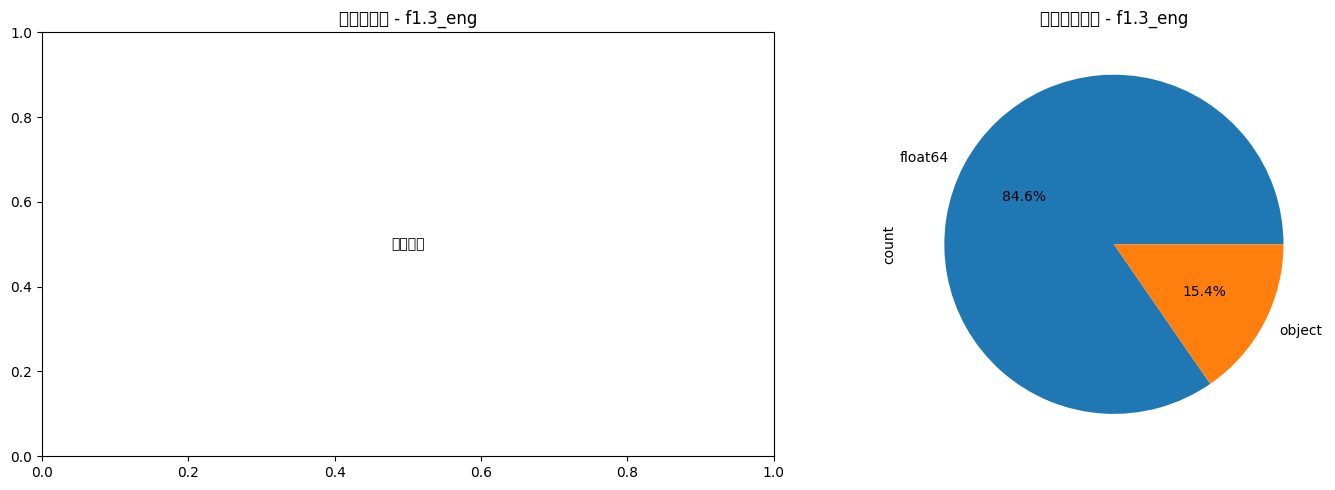

数据集: f1.3_eng
总行数: 39
总列数: 13
数值列数: 11
分类列数: 2



### 🔍 数据质量检查: f2.7_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

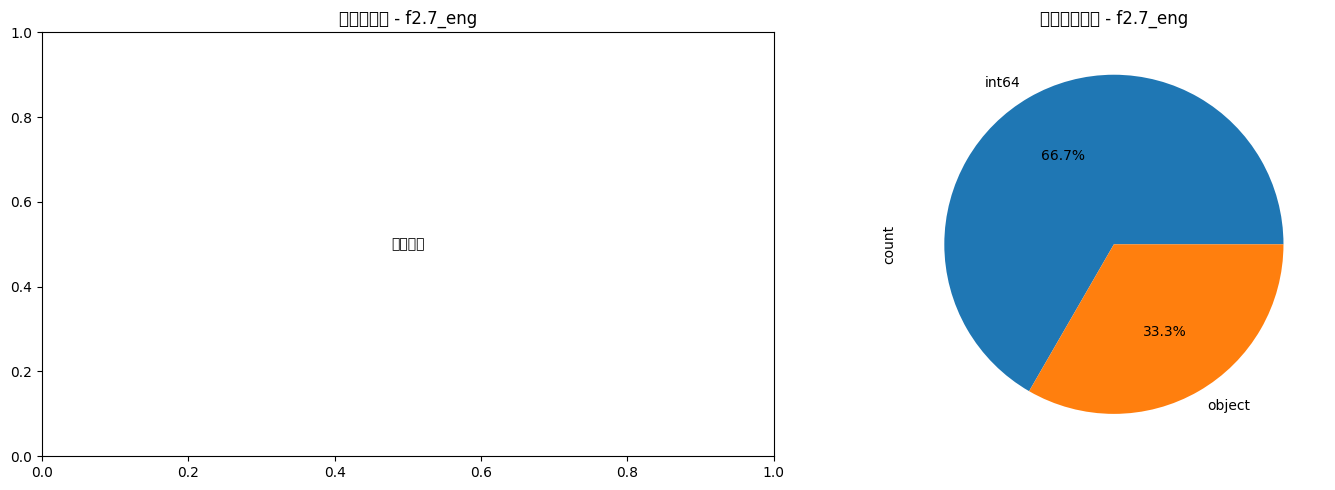

数据集: f2.7_eng
总行数: 20
总列数: 6
数值列数: 4
分类列数: 2



### 🔍 数据质量检查: f3.12_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

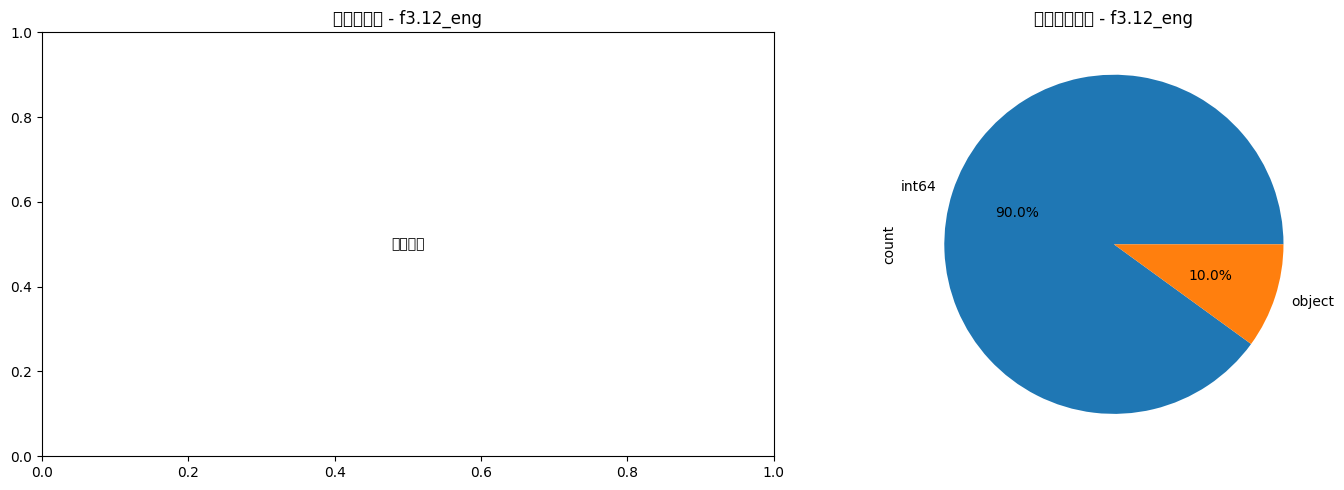

数据集: f3.12_eng
总行数: 14
总列数: 10
数值列数: 9
分类列数: 1



### 🔍 数据质量检查: f2.14_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

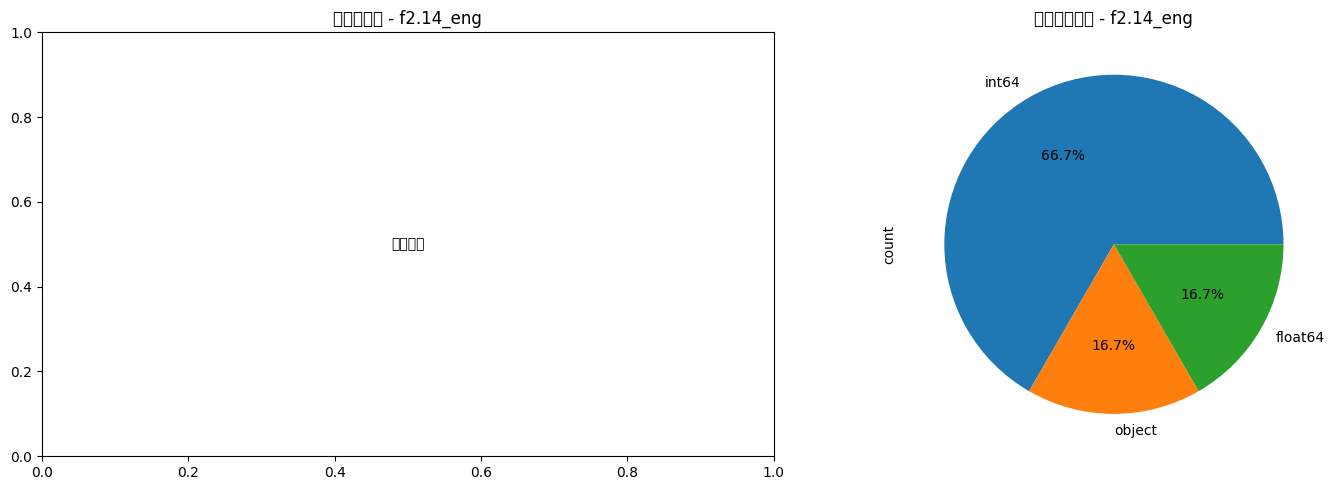

数据集: f2.14_eng
总行数: 22
总列数: 6
数值列数: 5
分类列数: 1



### 🔍 数据质量检查: f3.4_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

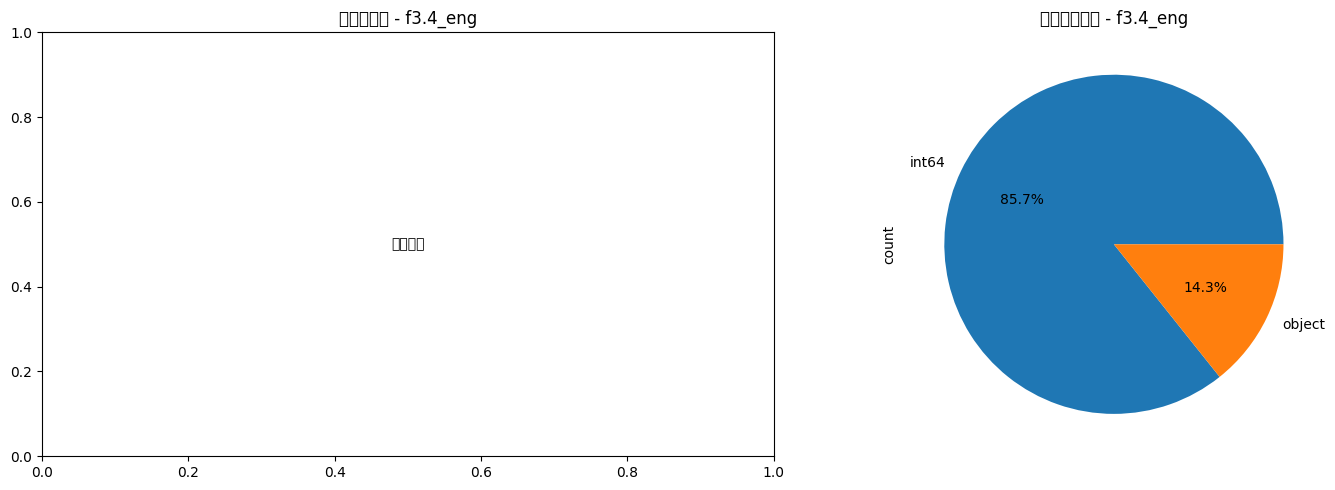

数据集: f3.4_eng
总行数: 23
总列数: 7
数值列数: 6
分类列数: 1



### 🔍 数据质量检查: f1.11_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

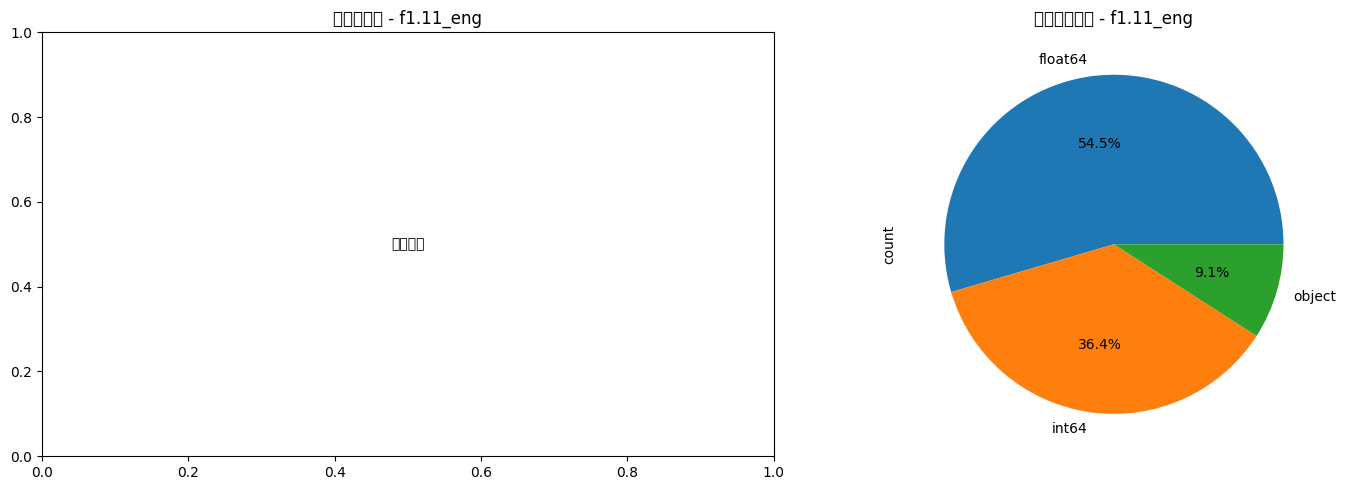

数据集: f1.11_eng
总行数: 20
总列数: 11
数值列数: 10
分类列数: 1



### 🔍 数据质量检查: f3.5_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

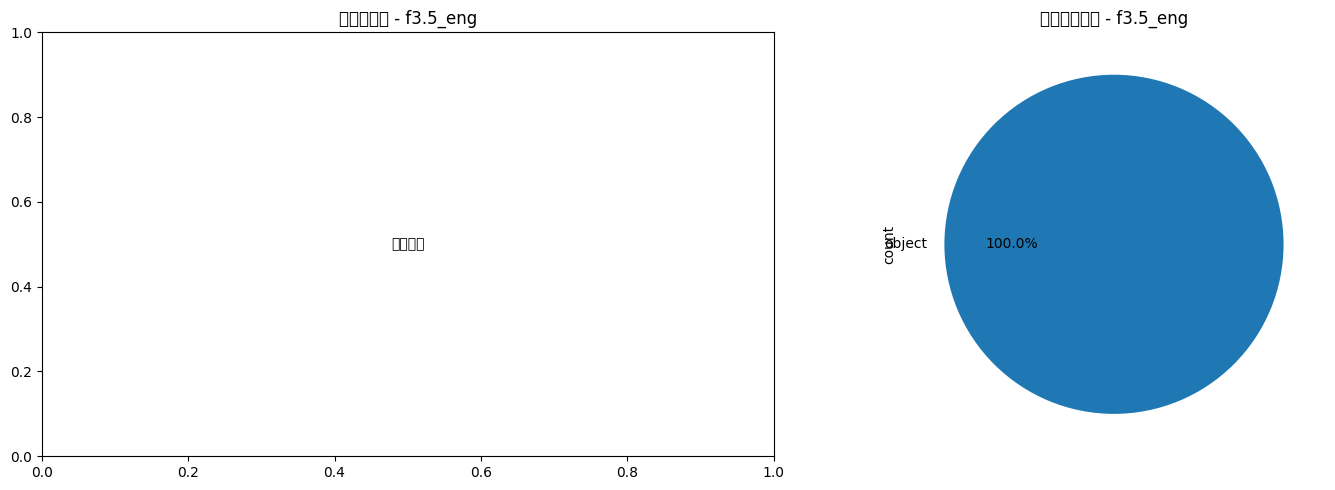

数据集: f3.5_eng
总行数: 41
总列数: 8
数值列数: 0
分类列数: 8



### 🔍 数据质量检查: f1.10_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

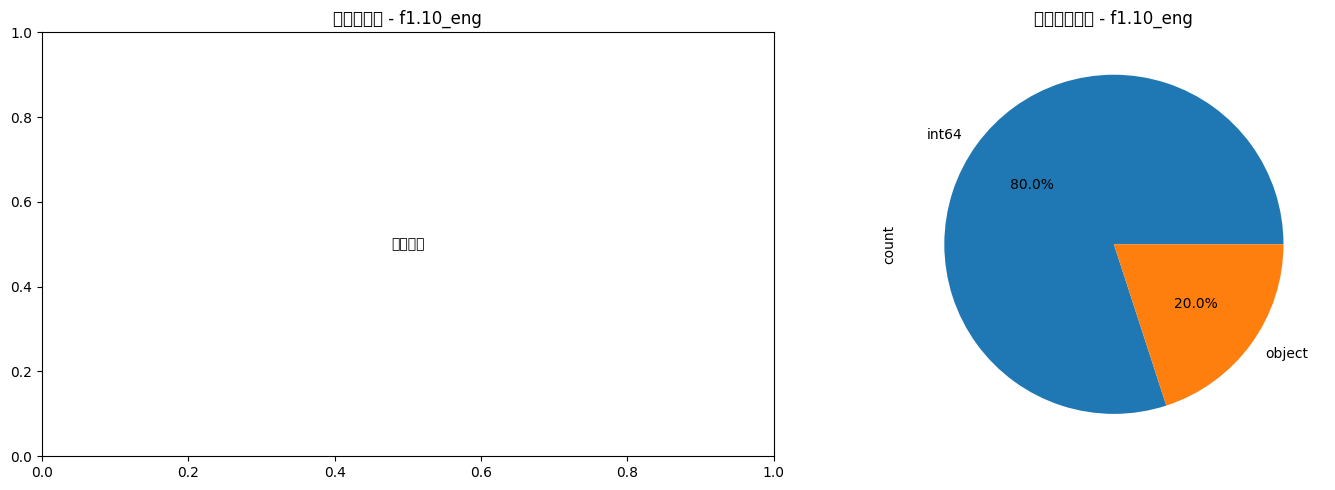

数据集: f1.10_eng
总行数: 20
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f1.2_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

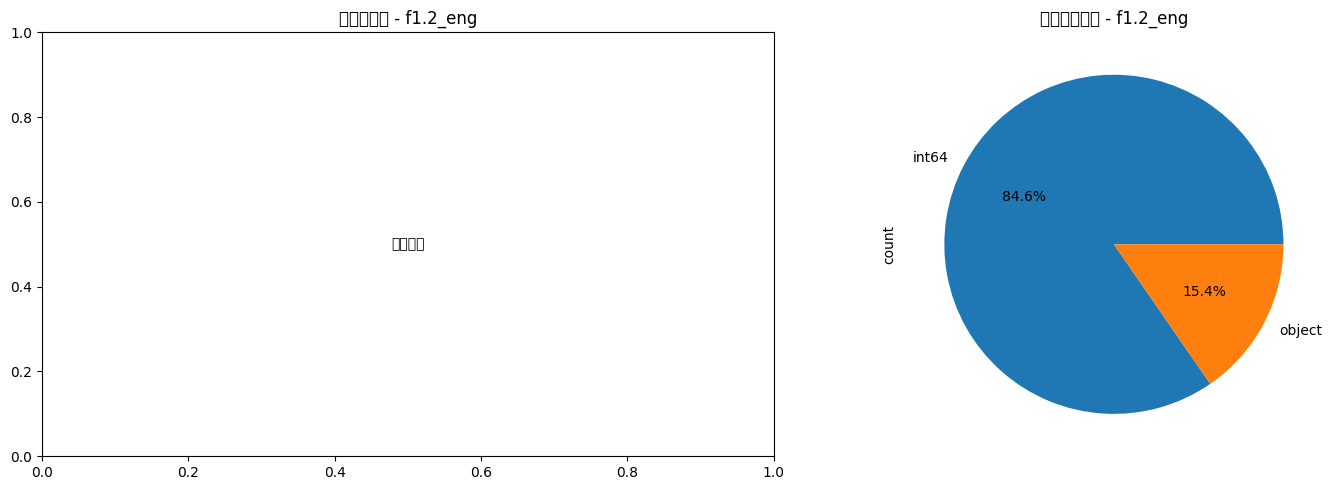

数据集: f1.2_eng
总行数: 36
总列数: 13
数值列数: 11
分类列数: 2



### 🔍 数据质量检查: f3.13_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

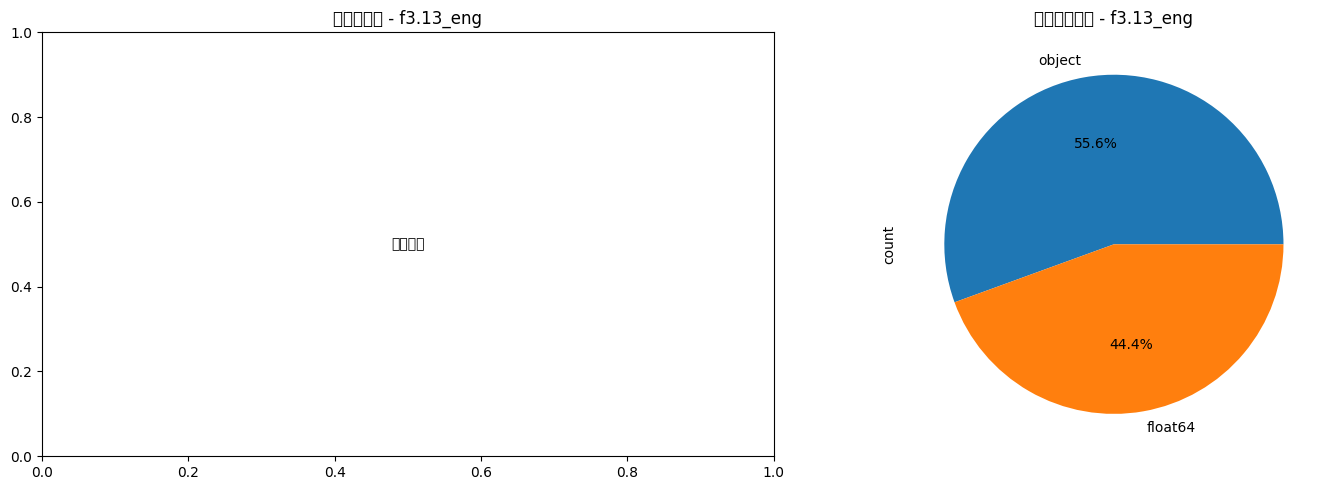

数据集: f3.13_eng
总行数: 13
总列数: 9
数值列数: 4
分类列数: 5



### 🔍 数据质量检查: f2.6_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

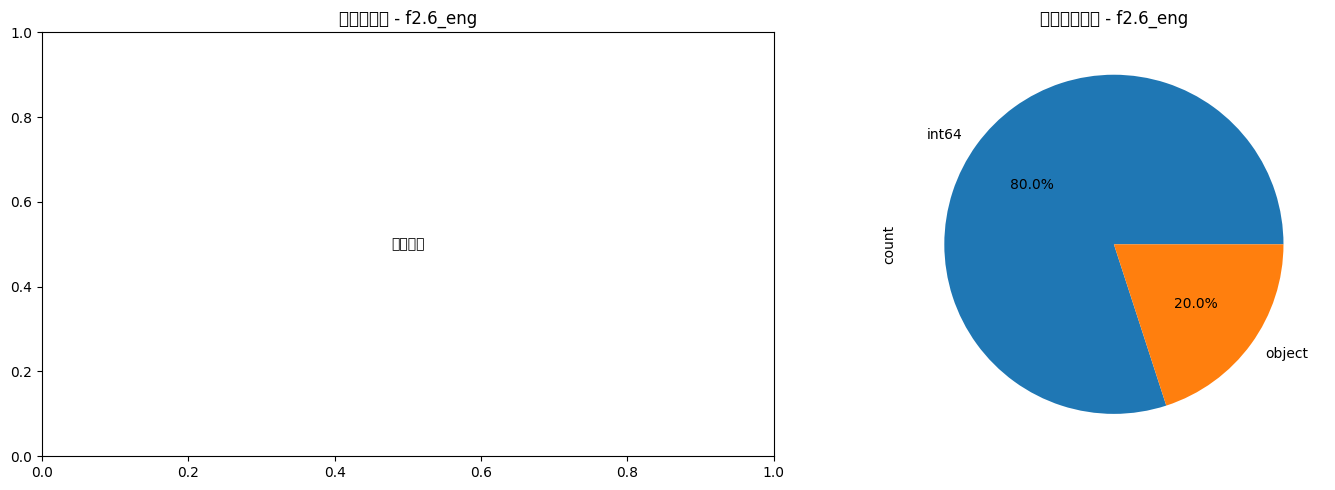

数据集: f2.6_eng
总行数: 22
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f2.15_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

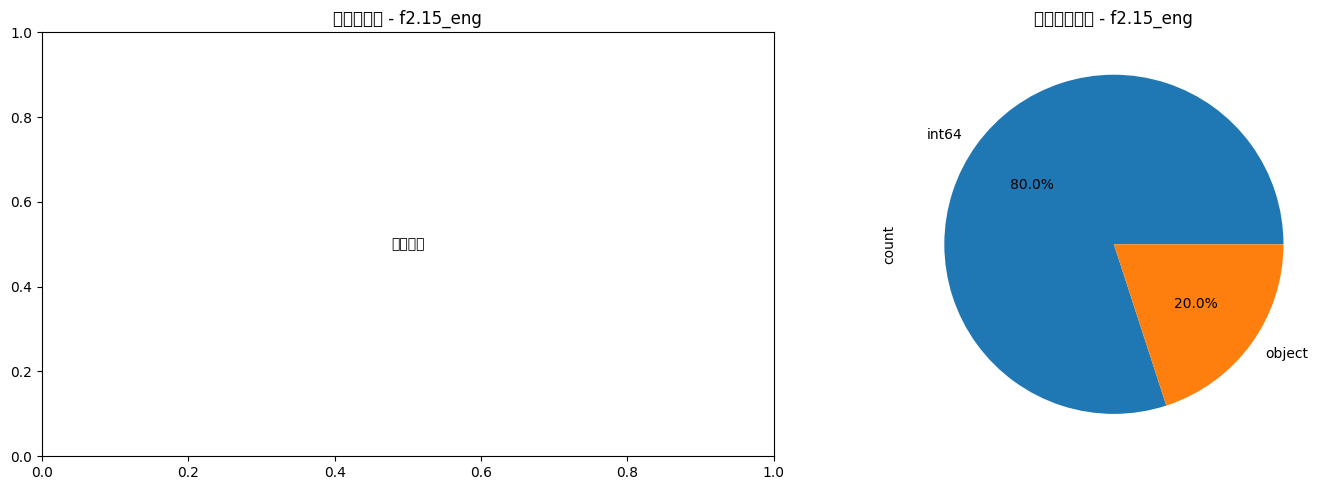

数据集: f2.15_eng
总行数: 4
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f1.9_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

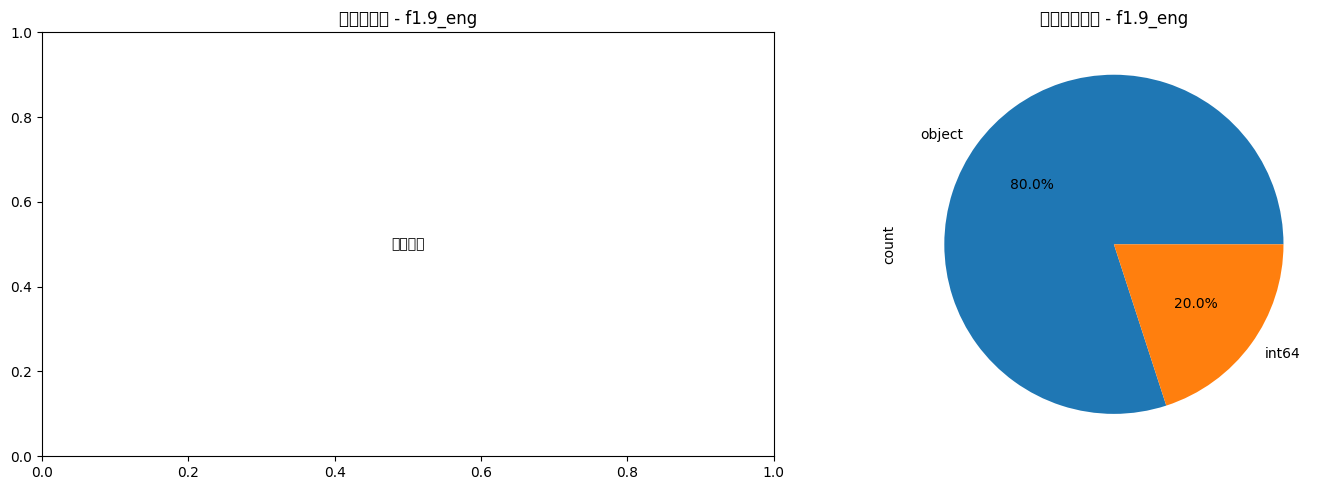

数据集: f1.9_eng
总行数: 108
总列数: 5
数值列数: 1
分类列数: 4



### 🔍 数据质量检查: f3.7_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

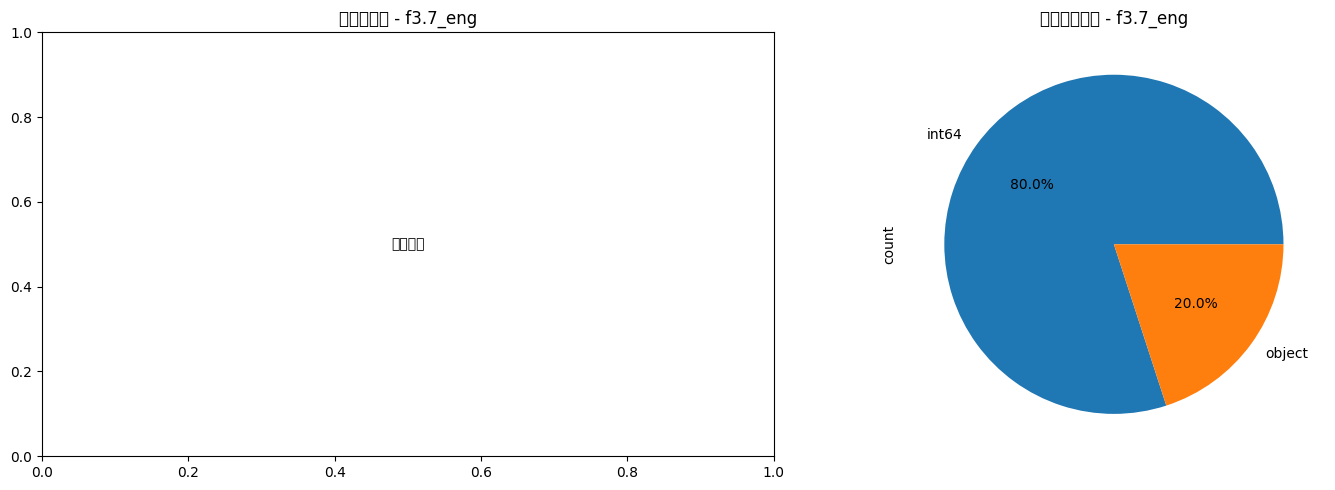

数据集: f3.7_eng
总行数: 11
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f1.12_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

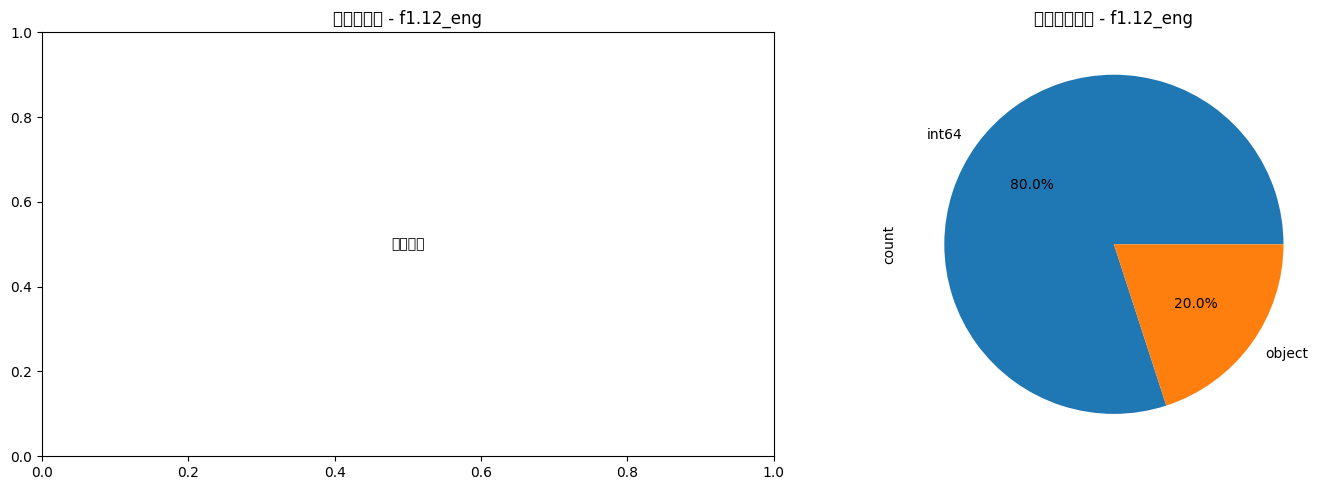

数据集: f1.12_eng
总行数: 8
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f3.11_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

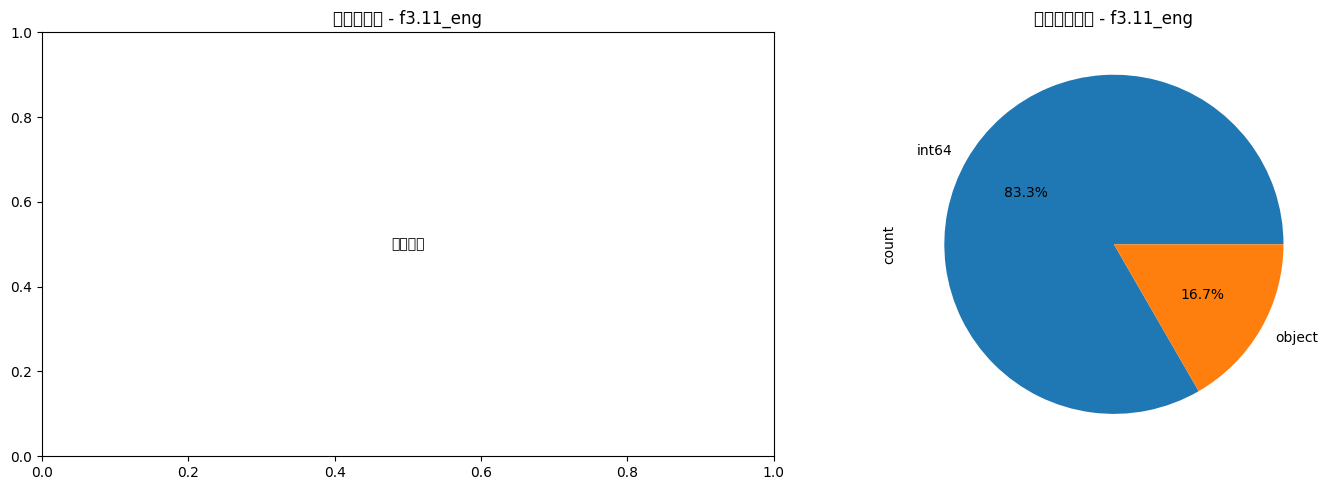

数据集: f3.11_eng
总行数: 6
总列数: 6
数值列数: 5
分类列数: 1



### 🔍 数据质量检查: f2.4_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

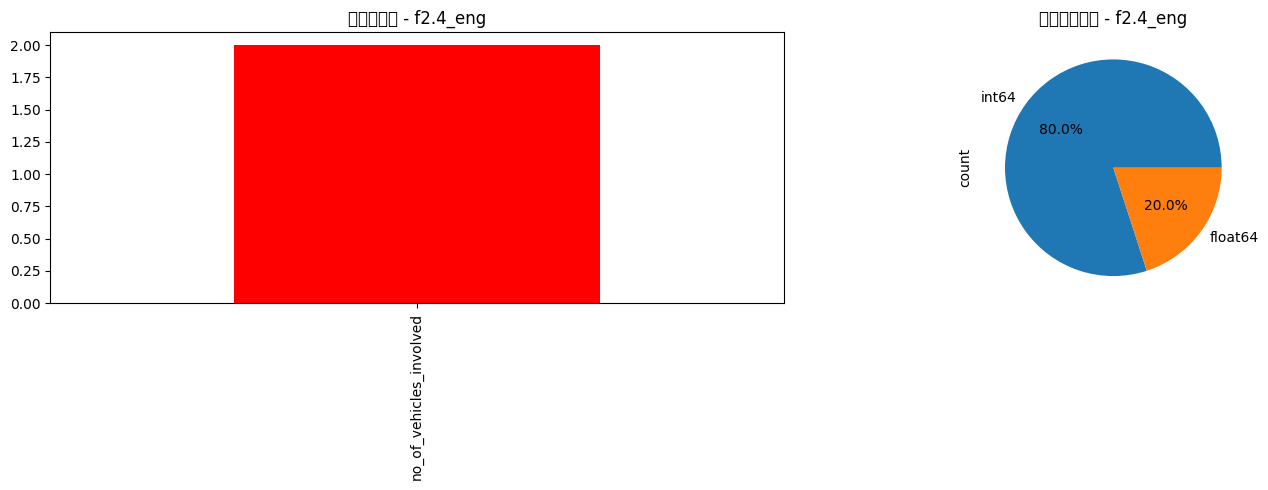

数据集: f2.4_eng
总行数: 6
总列数: 5
数值列数: 5
分类列数: 0



### 🔍 数据质量检查: f2.5_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

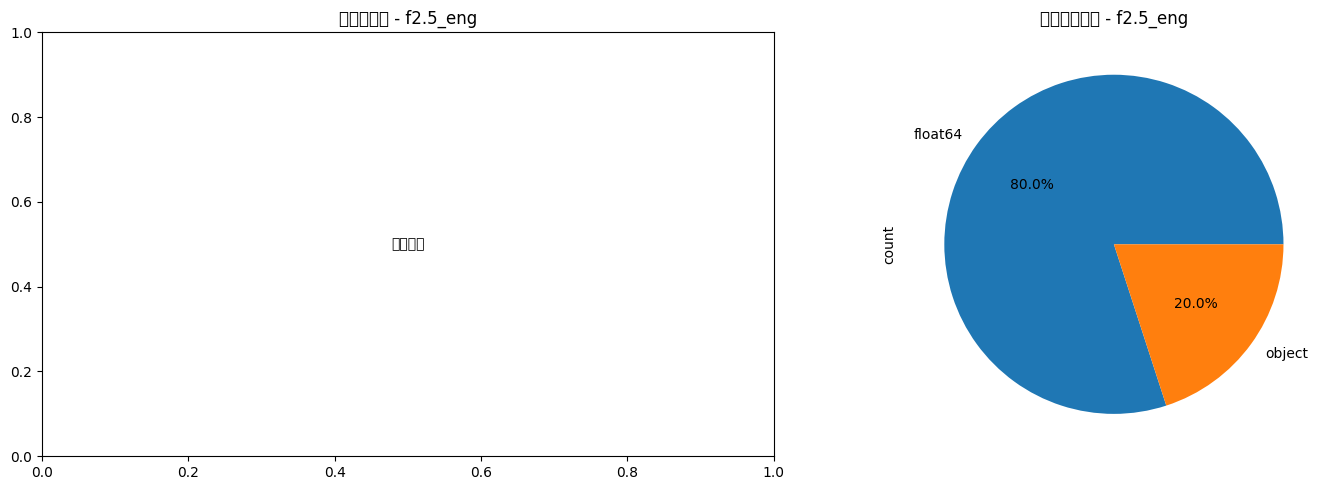

数据集: f2.5_eng
总行数: 51
总列数: 10
数值列数: 8
分类列数: 2



### 🔍 数据质量检查: f3.10_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

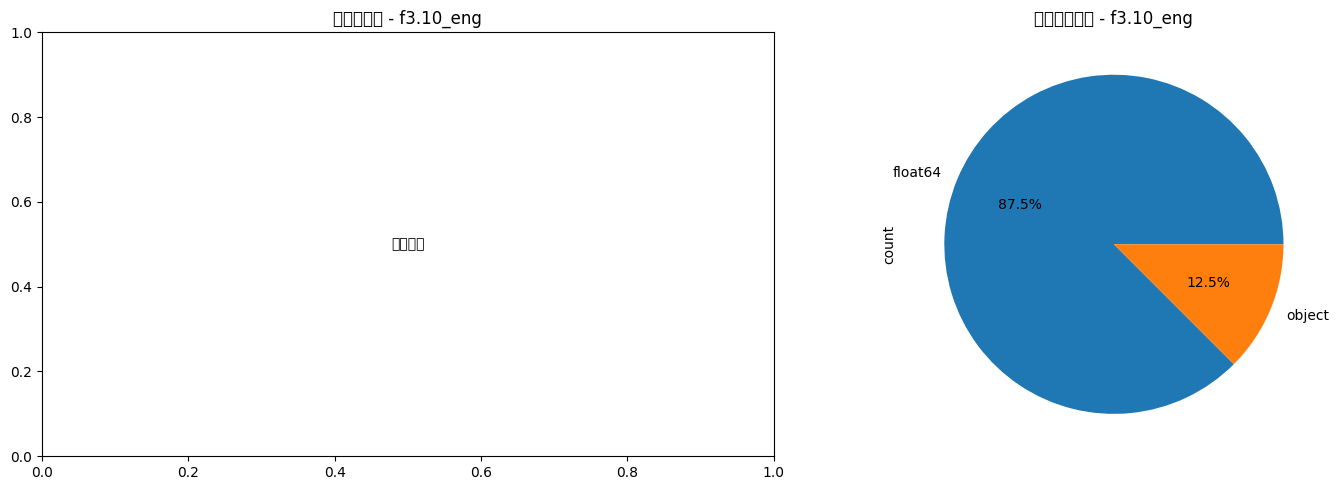

数据集: f3.10_eng
总行数: 19
总列数: 8
数值列数: 7
分类列数: 1



### 🔍 数据质量检查: f1.1_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

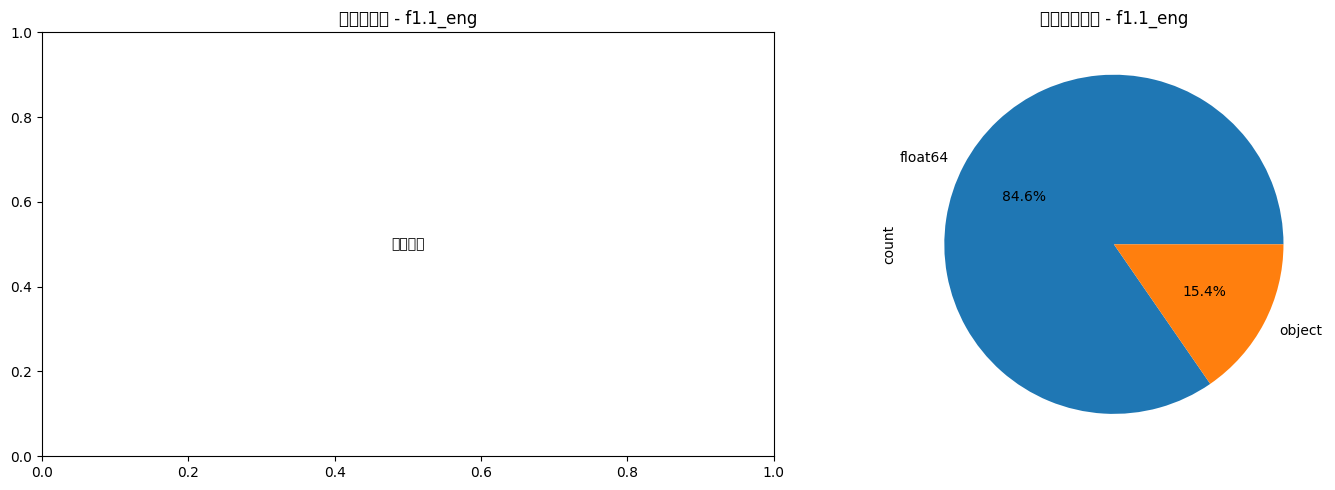

数据集: f1.1_eng
总行数: 39
总列数: 13
数值列数: 11
分类列数: 2



### 🔍 数据质量检查: f1.8_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

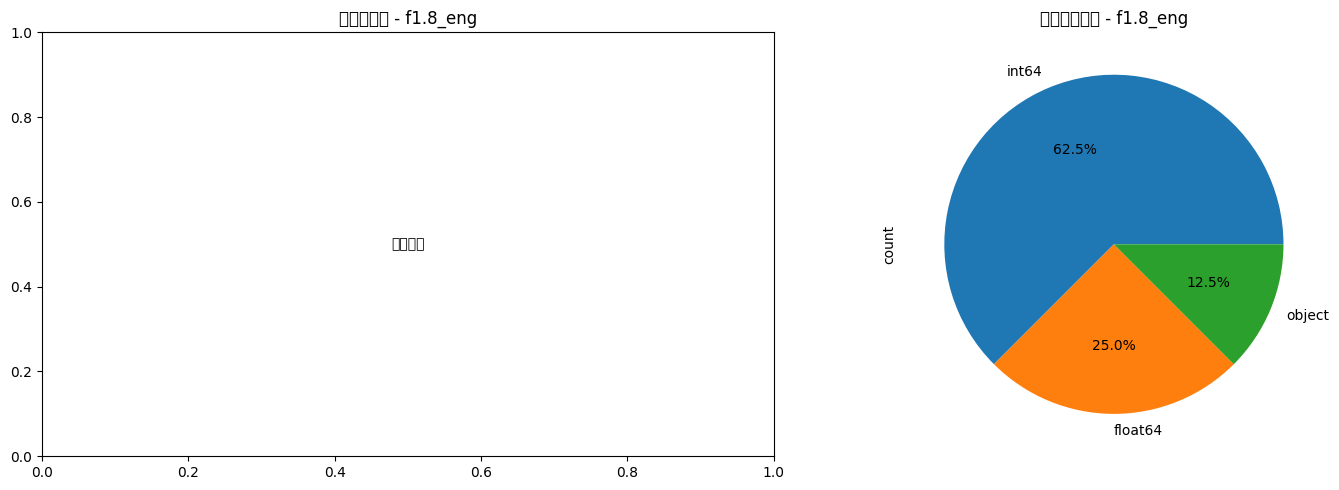

数据集: f1.8_eng
总行数: 18
总列数: 8
数值列数: 7
分类列数: 1



### 🔍 数据质量检查: f3.6_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

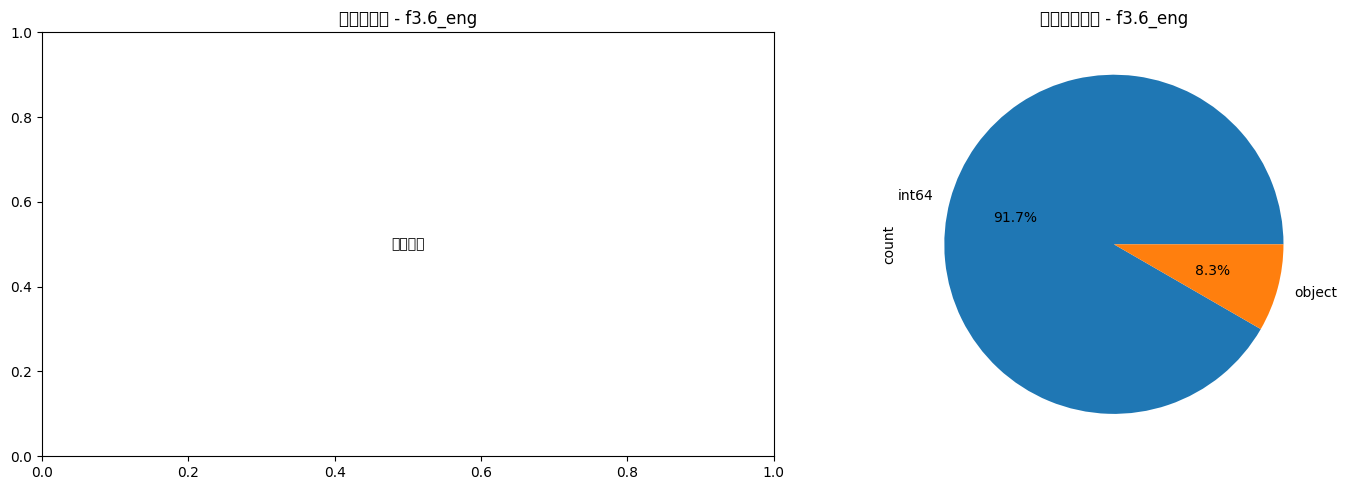

数据集: f3.6_eng
总行数: 19
总列数: 12
数值列数: 11
分类列数: 1



### 🔍 数据质量检查: f1.13_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

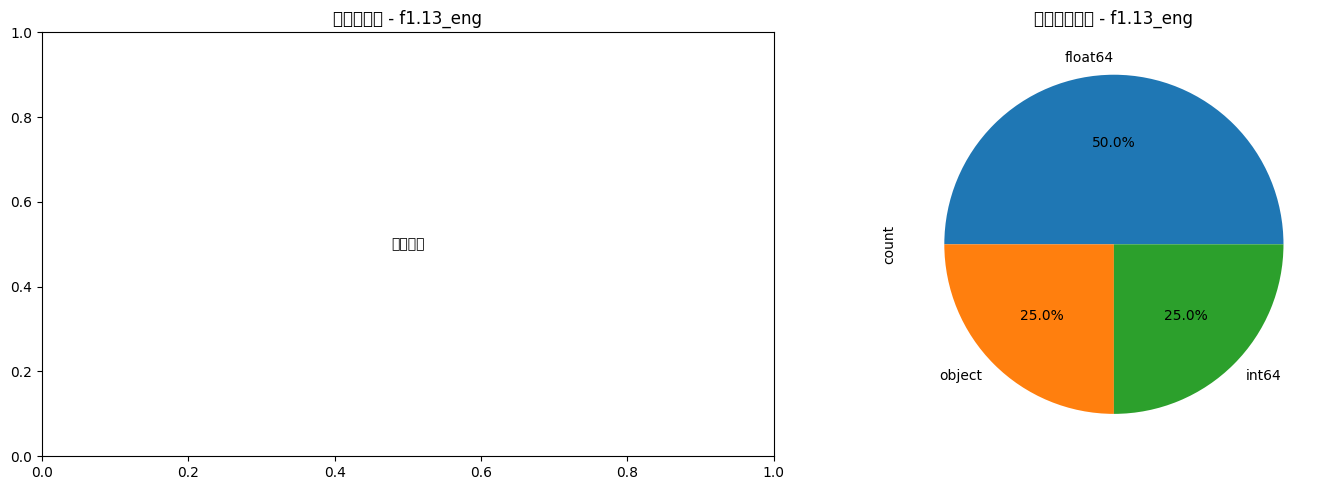

数据集: f1.13_eng
总行数: 19
总列数: 4
数值列数: 3
分类列数: 1



### 🔍 数据质量检查: f3.3_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

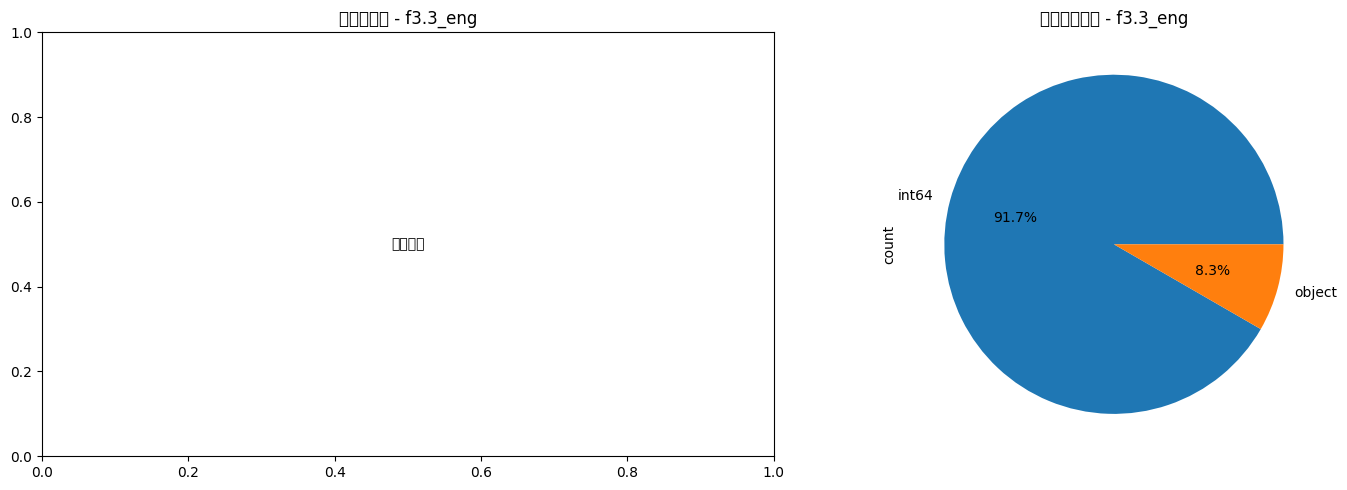

数据集: f3.3_eng
总行数: 19
总列数: 12
数值列数: 11
分类列数: 1



### 🔍 数据质量检查: f2.9_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

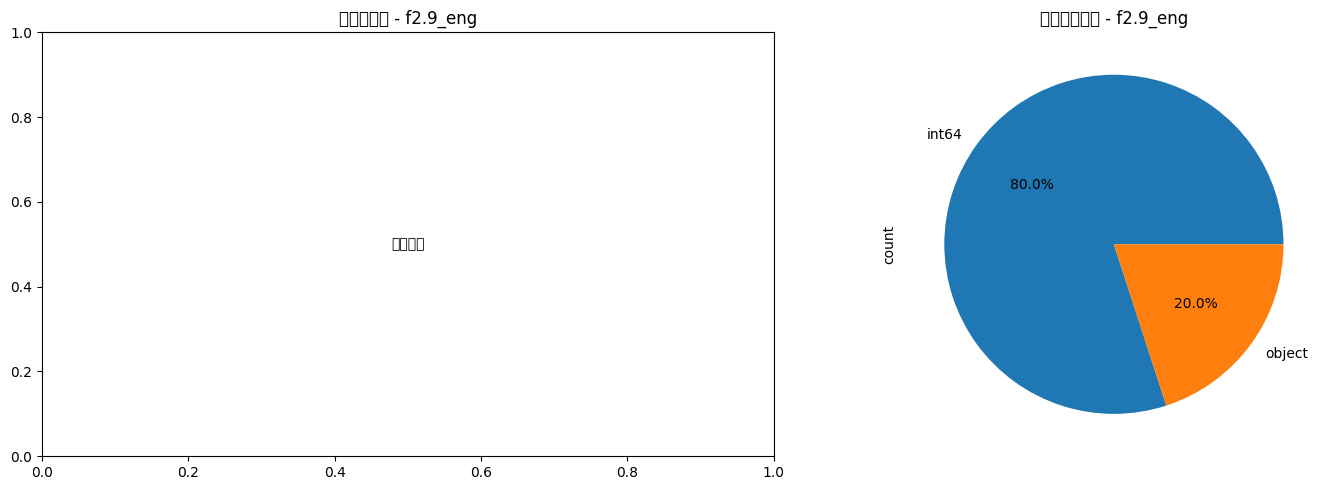

数据集: f2.9_eng
总行数: 13
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f2.13_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

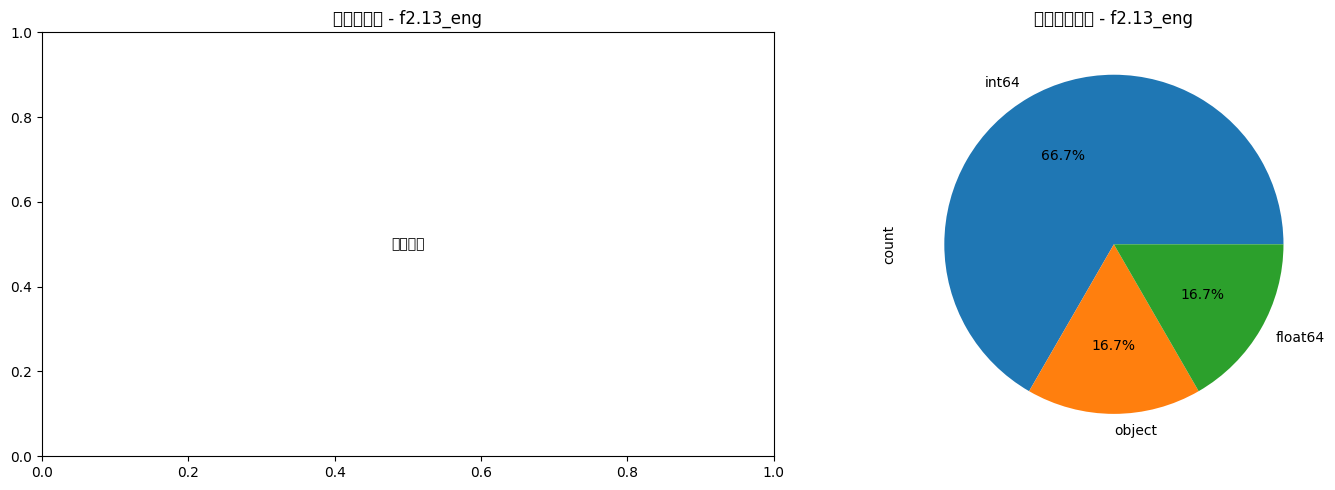

数据集: f2.13_eng
总行数: 20
总列数: 6
数值列数: 5
分类列数: 1



### 🔍 数据质量检查: f1.4_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

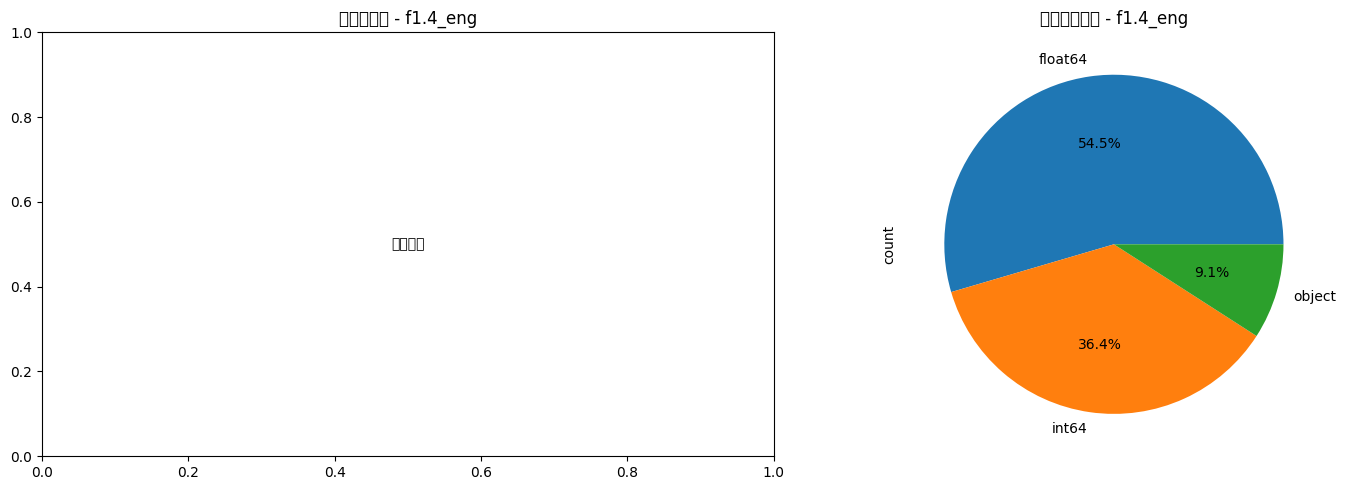

数据集: f1.4_eng
总行数: 20
总列数: 11
数值列数: 10
分类列数: 1



### 🔍 数据质量检查: fa1_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

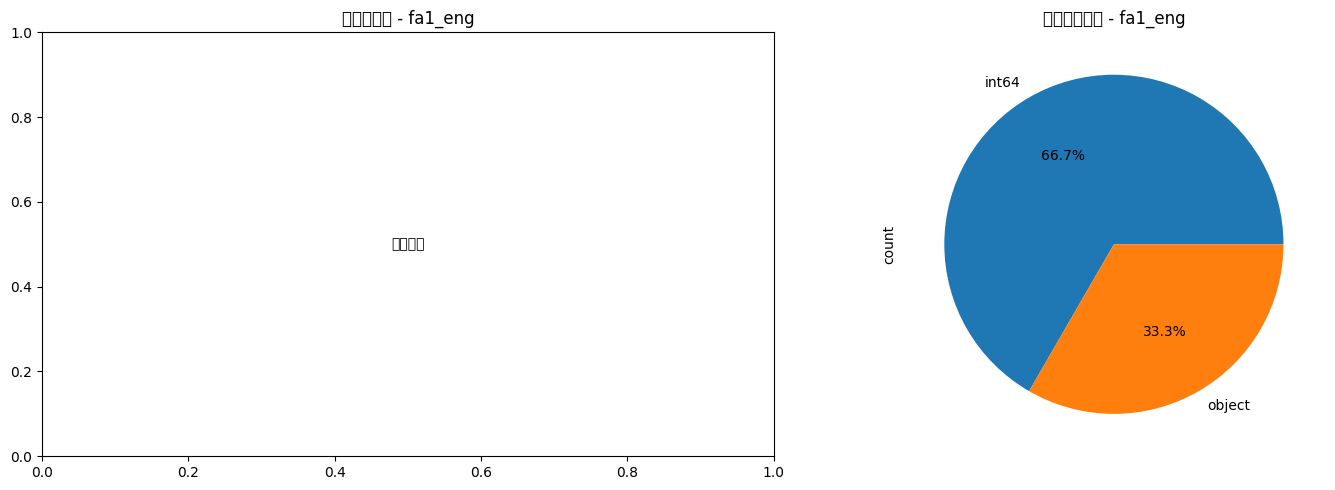

数据集: fa1_eng
总行数: 29
总列数: 3
数值列数: 2
分类列数: 1



### 🔍 数据质量检查: f2.12_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

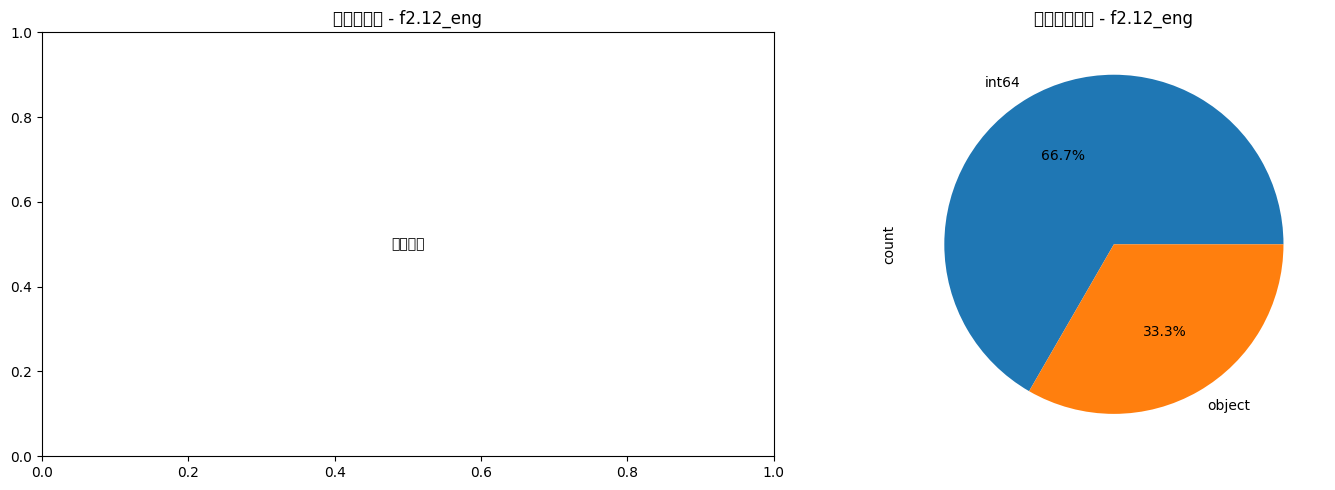

数据集: f2.12_eng
总行数: 29
总列数: 6
数值列数: 4
分类列数: 2



### 🔍 数据质量检查: f3.14_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

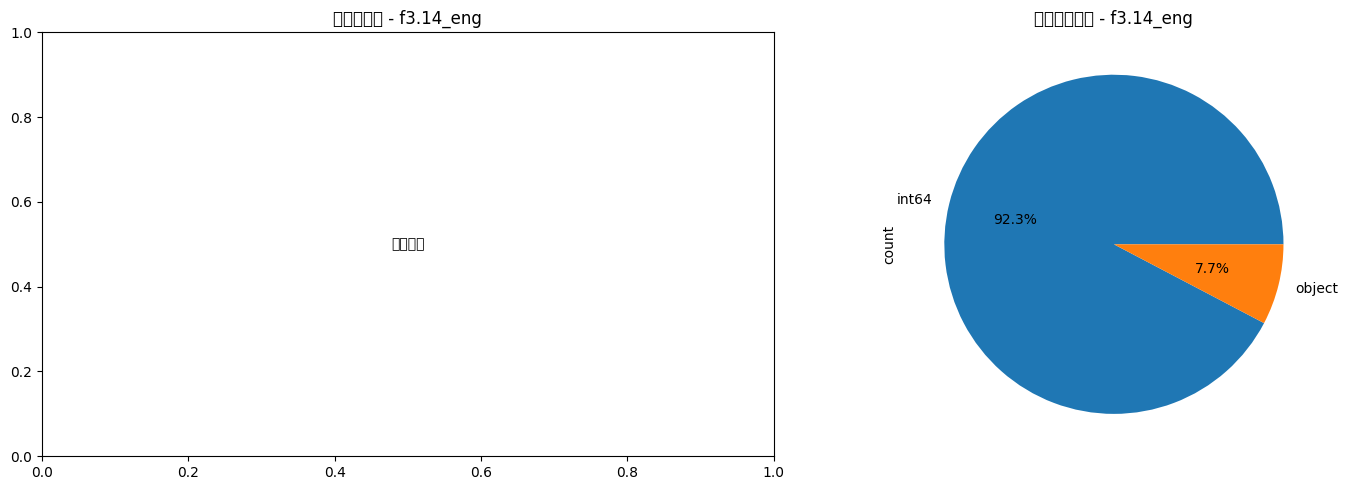

数据集: f3.14_eng
总行数: 20
总列数: 13
数值列数: 12
分类列数: 1



### 🔍 数据质量检查: f2.1_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

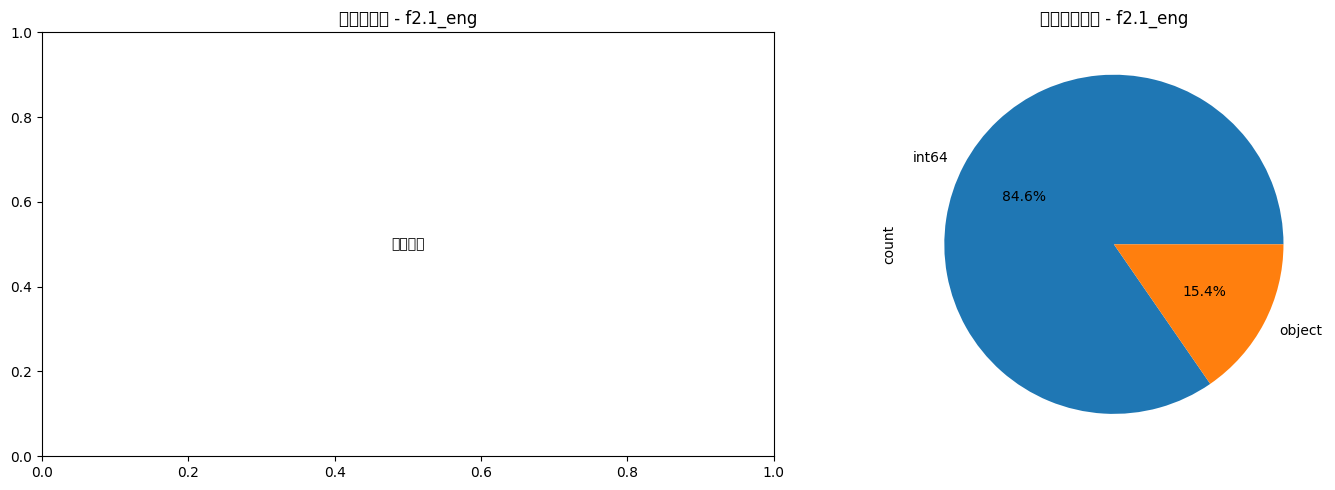

数据集: f2.1_eng
总行数: 16
总列数: 13
数值列数: 11
分类列数: 2



### 🔍 数据质量检查: f1.5_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

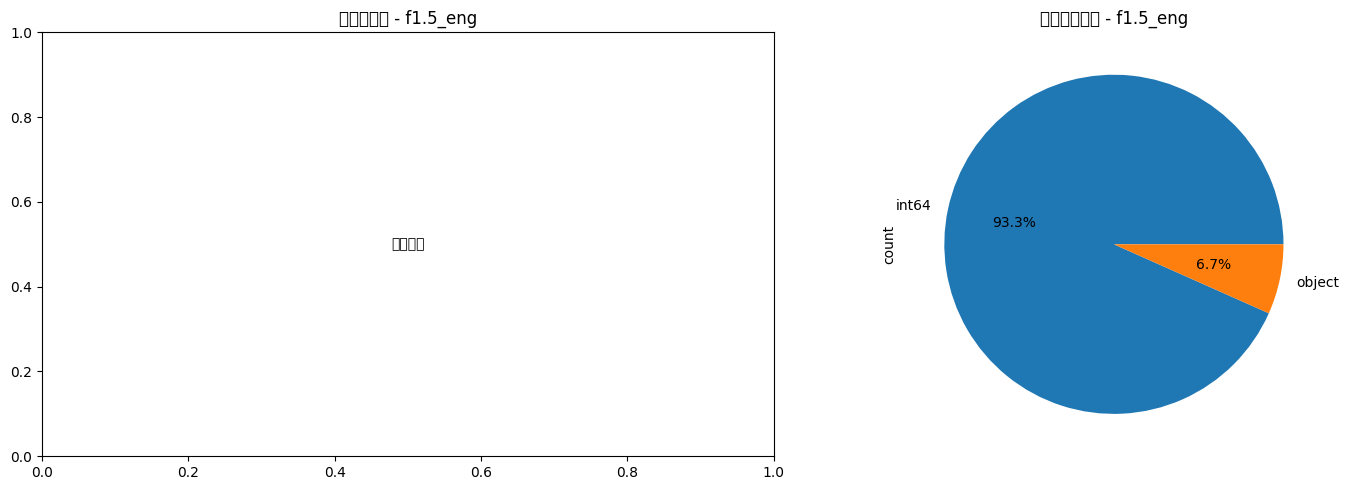

数据集: f1.5_eng
总行数: 20
总列数: 15
数值列数: 14
分类列数: 1



### 🔍 数据质量检查: key_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

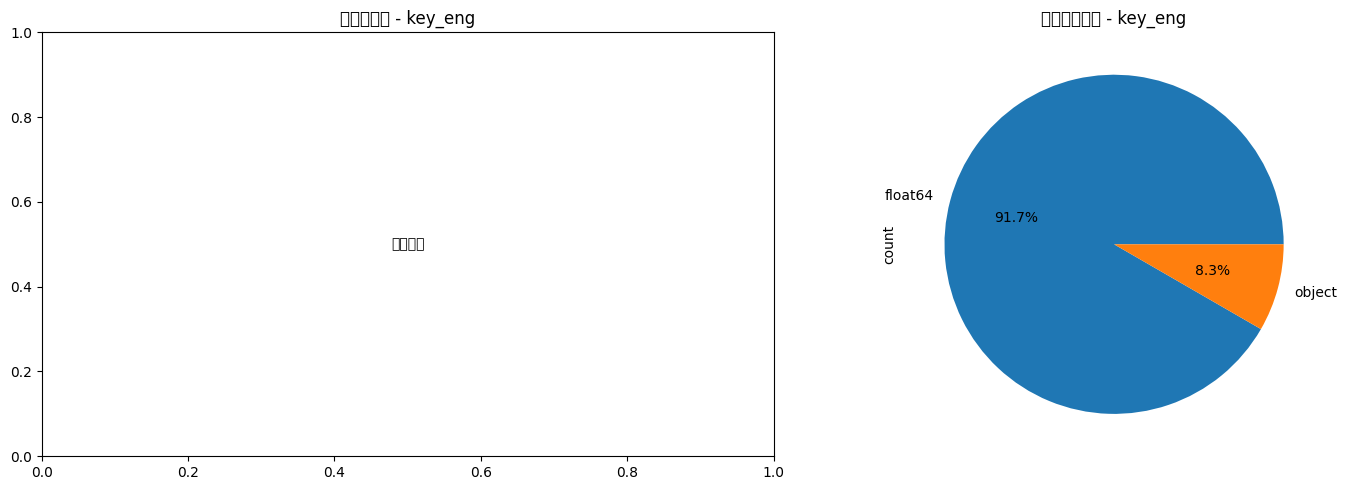

数据集: key_eng
总行数: 32
总列数: 12
数值列数: 11
分类列数: 1



### 🔍 数据质量检查: f3.2_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

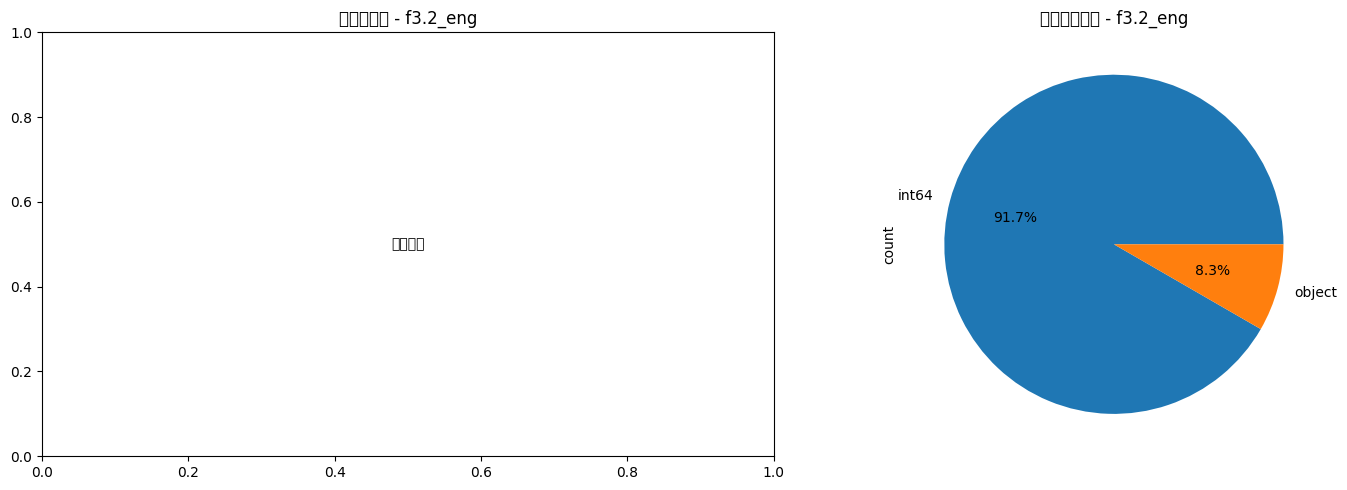

数据集: f3.2_eng
总行数: 17
总列数: 12
数值列数: 11
分类列数: 1



### 🔍 数据质量检查: f2.8_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

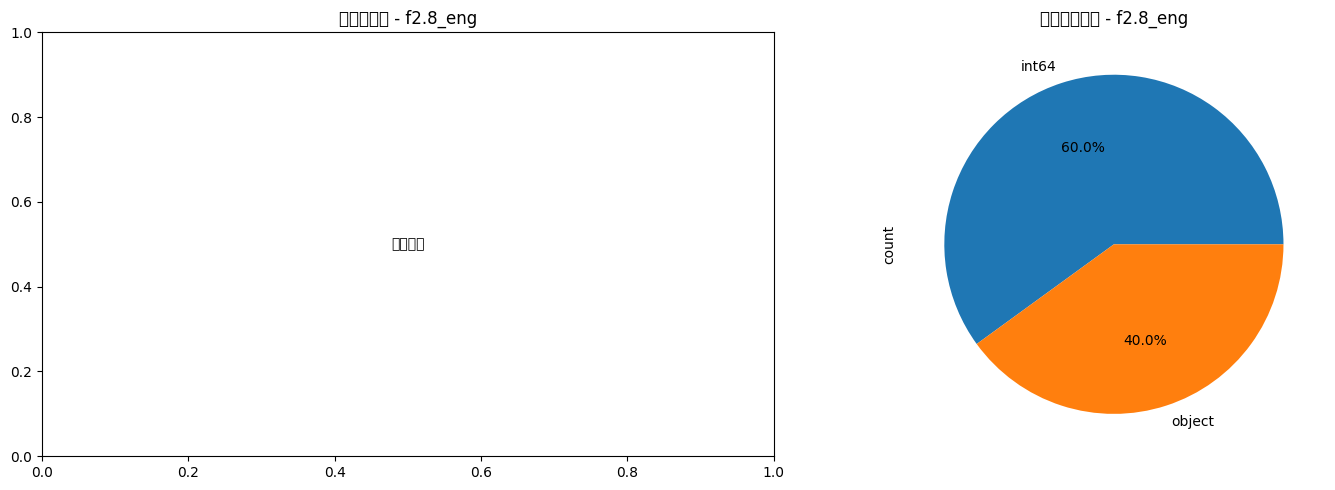

数据集: f2.8_eng
总行数: 20
总列数: 5
数值列数: 3
分类列数: 2



### 🔍 数据质量检查: f2.10_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

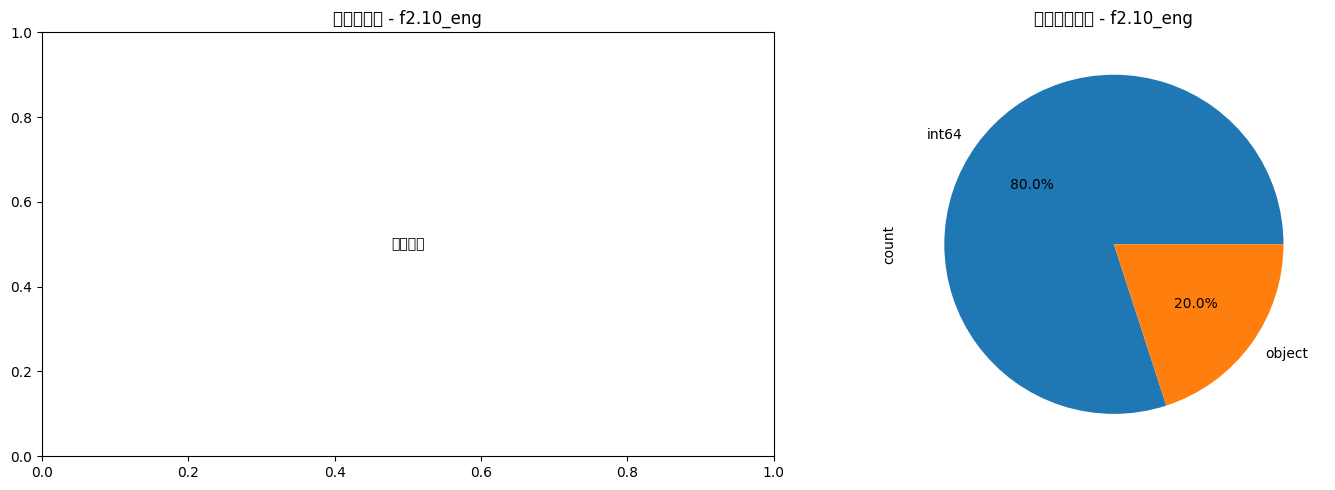

数据集: f2.10_eng
总行数: 14
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f1.7_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

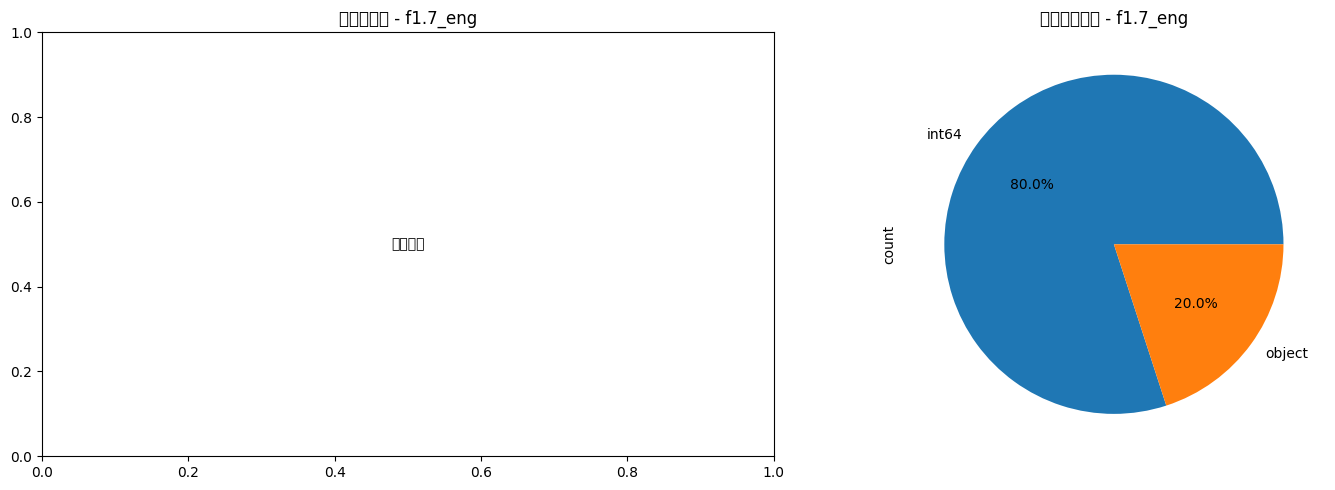

数据集: f1.7_eng
总行数: 16
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f3.9_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

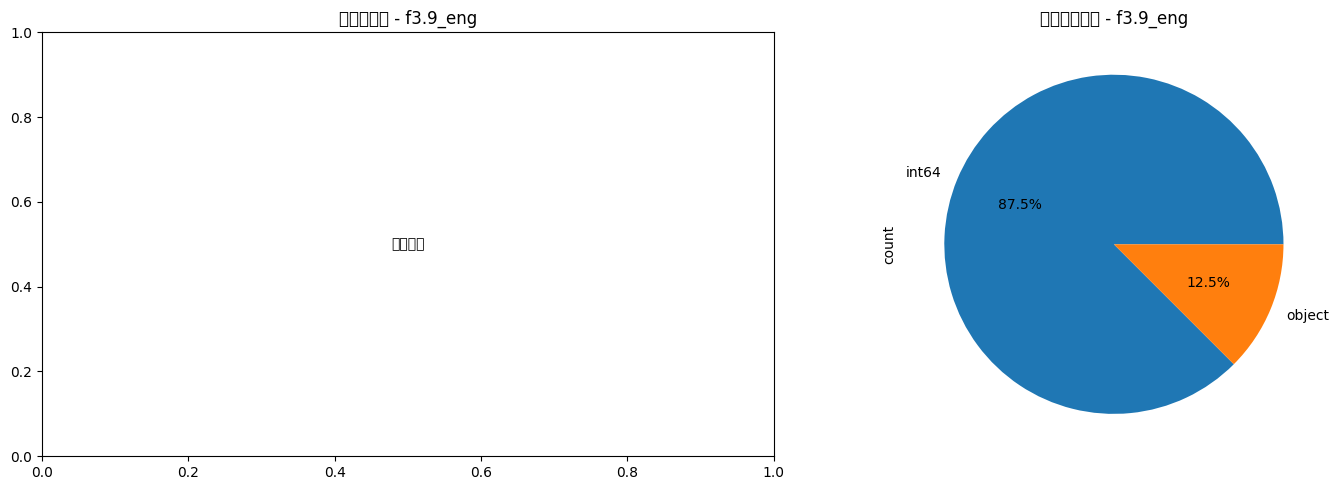

数据集: f3.9_eng
总行数: 20
总列数: 8
数值列数: 7
分类列数: 1



### 🔍 数据质量检查: f2.3_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

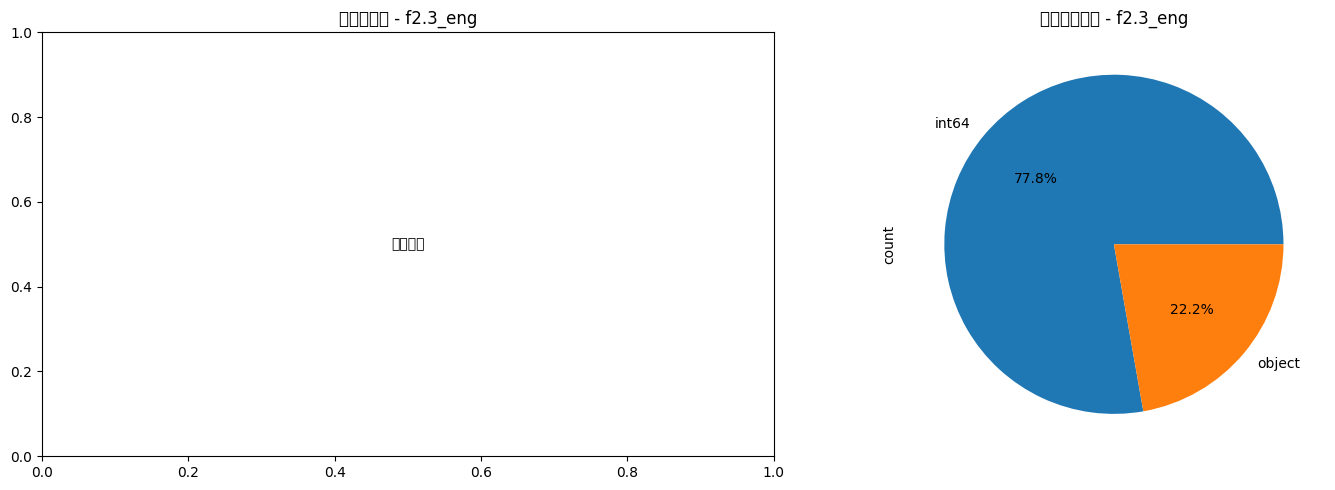

数据集: f2.3_eng
总行数: 20
总列数: 9
数值列数: 7
分类列数: 2



### 🔍 数据质量检查: f1.14_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

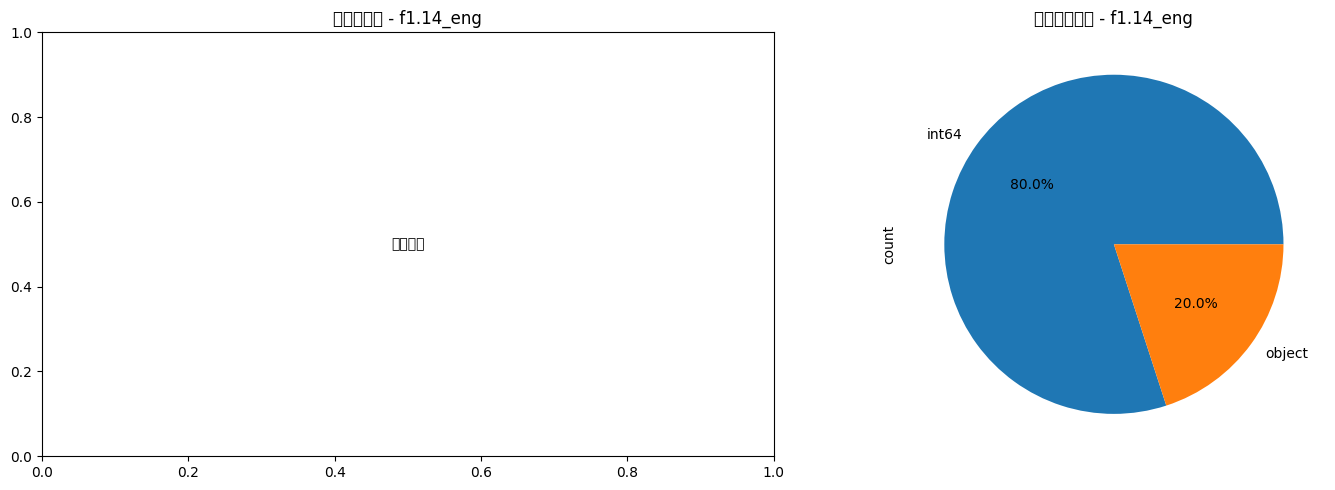

数据集: f1.14_eng
总行数: 4
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f3.1_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

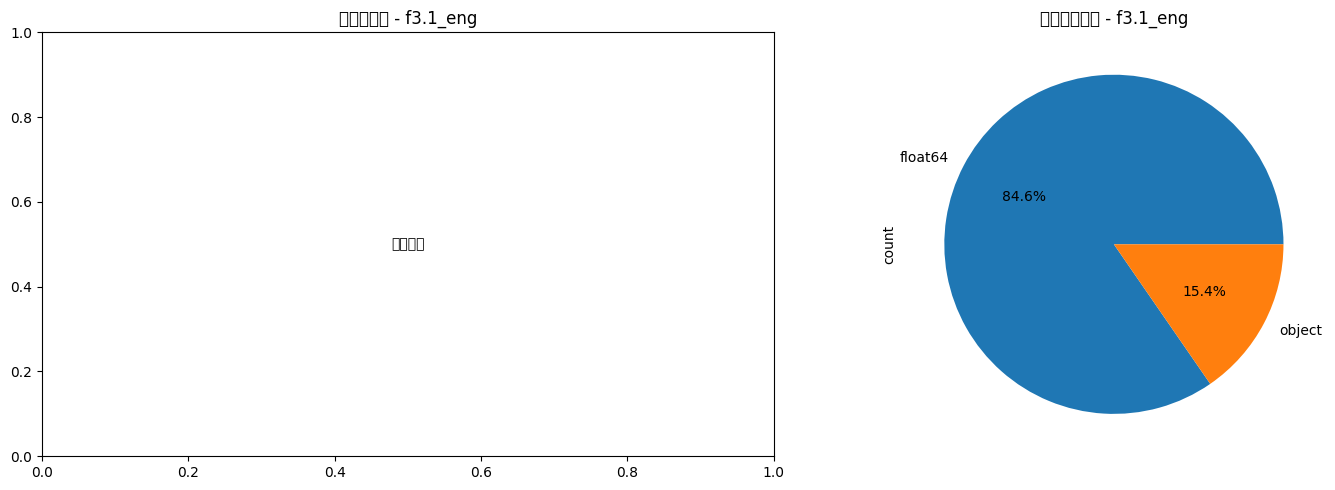

数据集: f3.1_eng
总行数: 55
总列数: 13
数值列数: 11
分类列数: 2



### 🔍 数据质量检查: f2.11_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

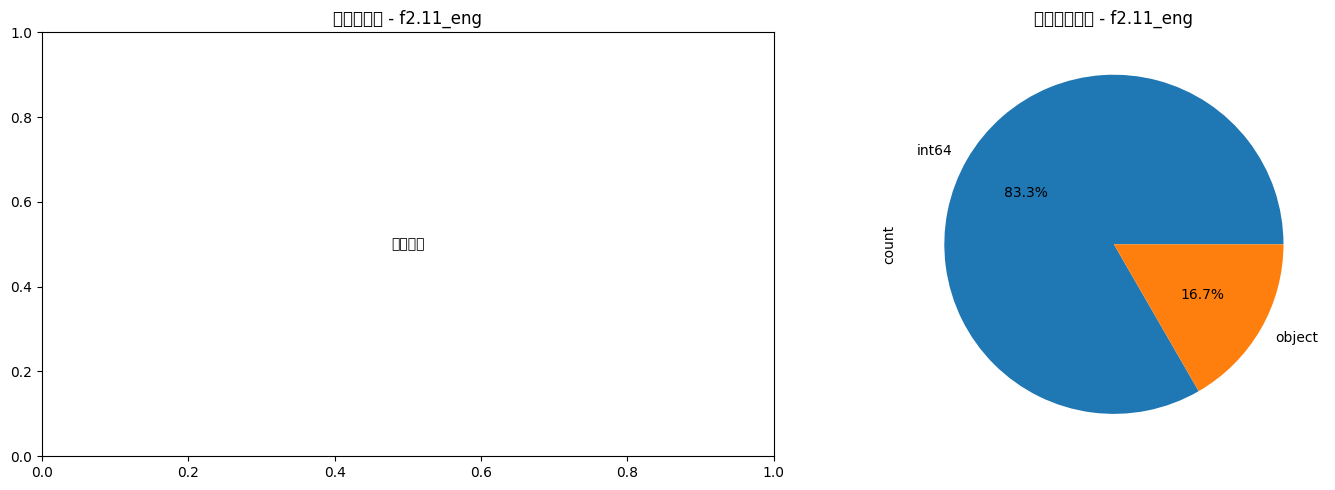

数据集: f2.11_eng
总行数: 4
总列数: 6
数值列数: 5
分类列数: 1



### 🔍 数据质量检查: f1.6_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

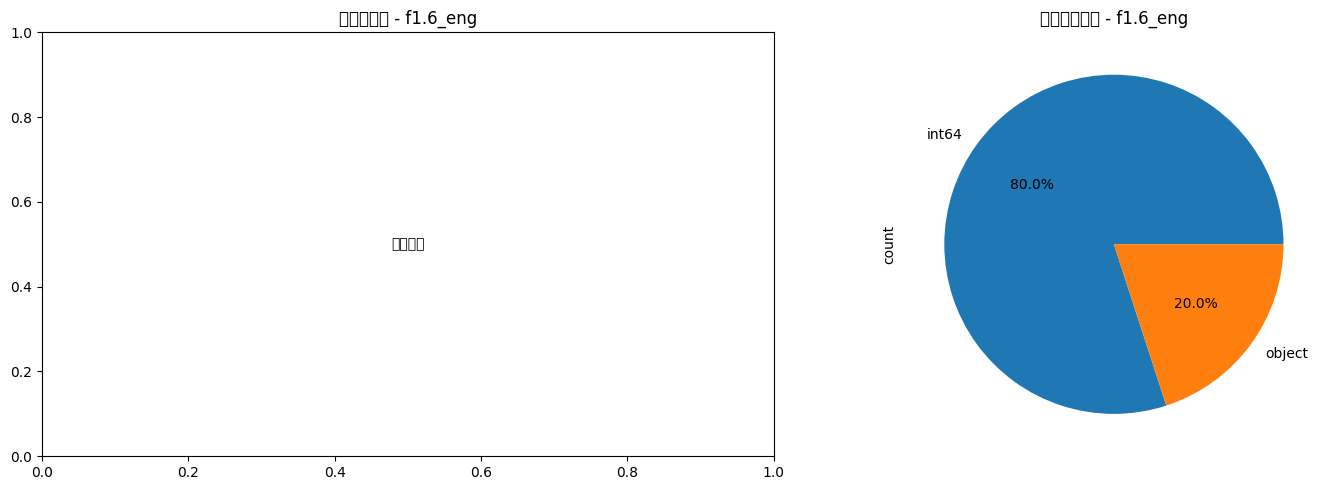

数据集: f1.6_eng
总行数: 6
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f3.8_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

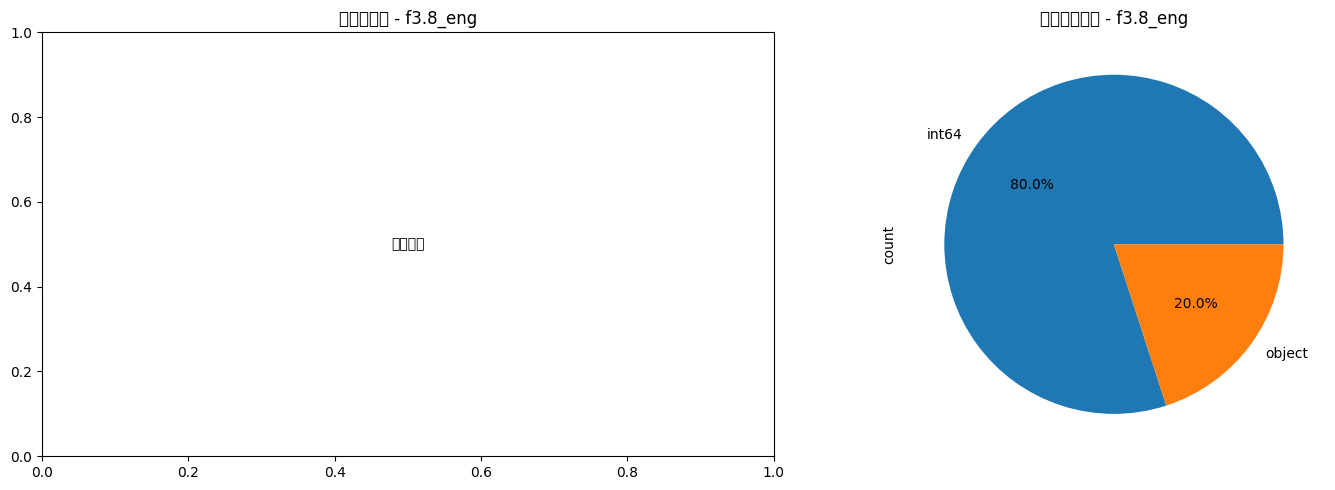

数据集: f3.8_eng
总行数: 41
总列数: 5
数值列数: 4
分类列数: 1



### 🔍 数据质量检查: f2.2_eng

/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32570 (\N{CJK UNIFIED IDEOGRAPH-7F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/1496464370.py:35: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs88

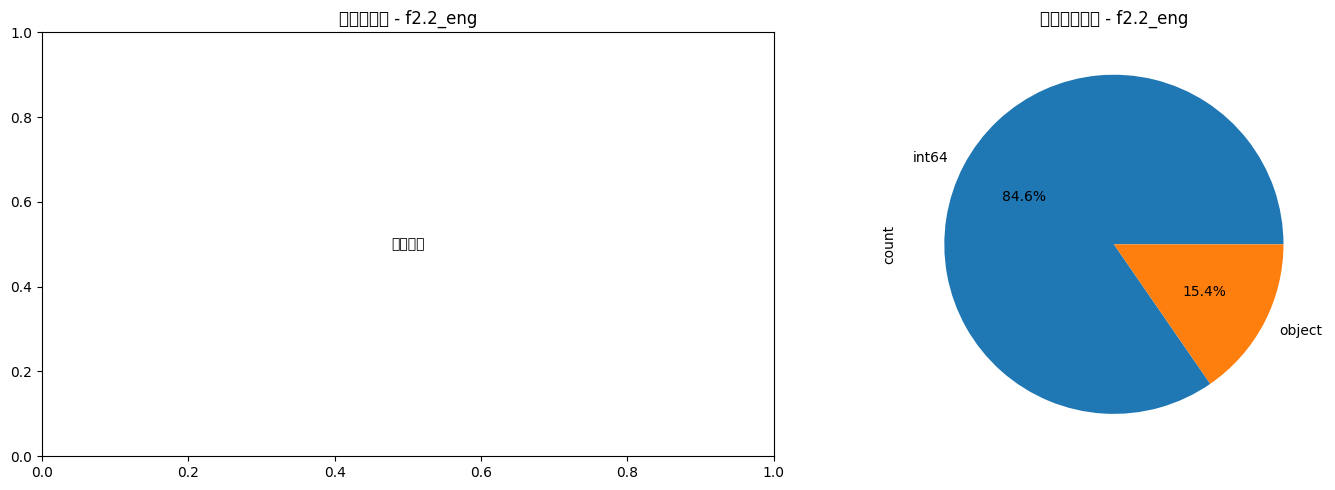

数据集: f2.2_eng
总行数: 20
总列数: 13
数值列数: 11
分类列数: 2



In [11]:
# 单元格 8: 数据质量检查
display(Markdown("## 数据质量检查"))

if cleaner.cleaned_data:
    for name, df in cleaner.cleaned_data.items():
        display(Markdown(f"### 🔍 数据质量检查: {name}"))

        # 创建子图
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # 缺失值可视化
        missing_data = df.isnull().sum()
        missing_data = missing_data[missing_data > 0]
        if len(missing_data) > 0:
            missing_data.plot(
                kind="bar", ax=axes[0], title=f"缺失值统计 - {name}", color="red"
            )
        else:
            axes[0].text(
                0.5,
                0.5,
                "无缺失值",
                ha="center",
                va="center",
                transform=axes[0].transAxes,
            )
            axes[0].set_title(f"缺失值统计 - {name}")

        # 数据类型分布
        dtypes_count = df.dtypes.value_counts()
        dtypes_count.plot(
            kind="pie", ax=axes[1], autopct="%1.1f%%", title=f"数据类型分布 - {name}"
        )

        plt.tight_layout()
        plt.show()

        # 基本统计信息
        print(f"数据集: {name}")
        print(f"总行数: {len(df)}")
        print(f"总列数: {len(df.columns)}")
        print(f"数值列数: {len(df.select_dtypes(include=[np.number]).columns)}")
        print(f"分类列数: {len(df.select_dtypes(include=['object']).columns)}")
        print("\n" + "=" * 50)

## 📈 数据清洗概览

,Dataset,Rows,Columns,Numeric Columns,Categorical Columns,Total Missing
0,f1.3_eng,39,13,11,2,0
1,f2.7_eng,20,6,4,2,0
2,f3.12_eng,14,10,9,1,0
3,f2.14_eng,22,6,5,1,0
4,f3.4_eng,23,7,6,1,0
5,f1.11_eng,20,11,10,1,0
6,f3.5_eng,41,8,0,8,0
7,f1.10_eng,20,5,4,1,0
8,f1.2_eng,36,13,11,2,0
9,f3.13_eng,13,9,4,5,0


/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/856403688.py:71: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/856403688.py:71: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/856403688.py:71: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/856403688.py:71: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb125v6xmzdr27py7p40000gn/T/ipykernel_32499/856403688.py:71: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vz/zs883bb12

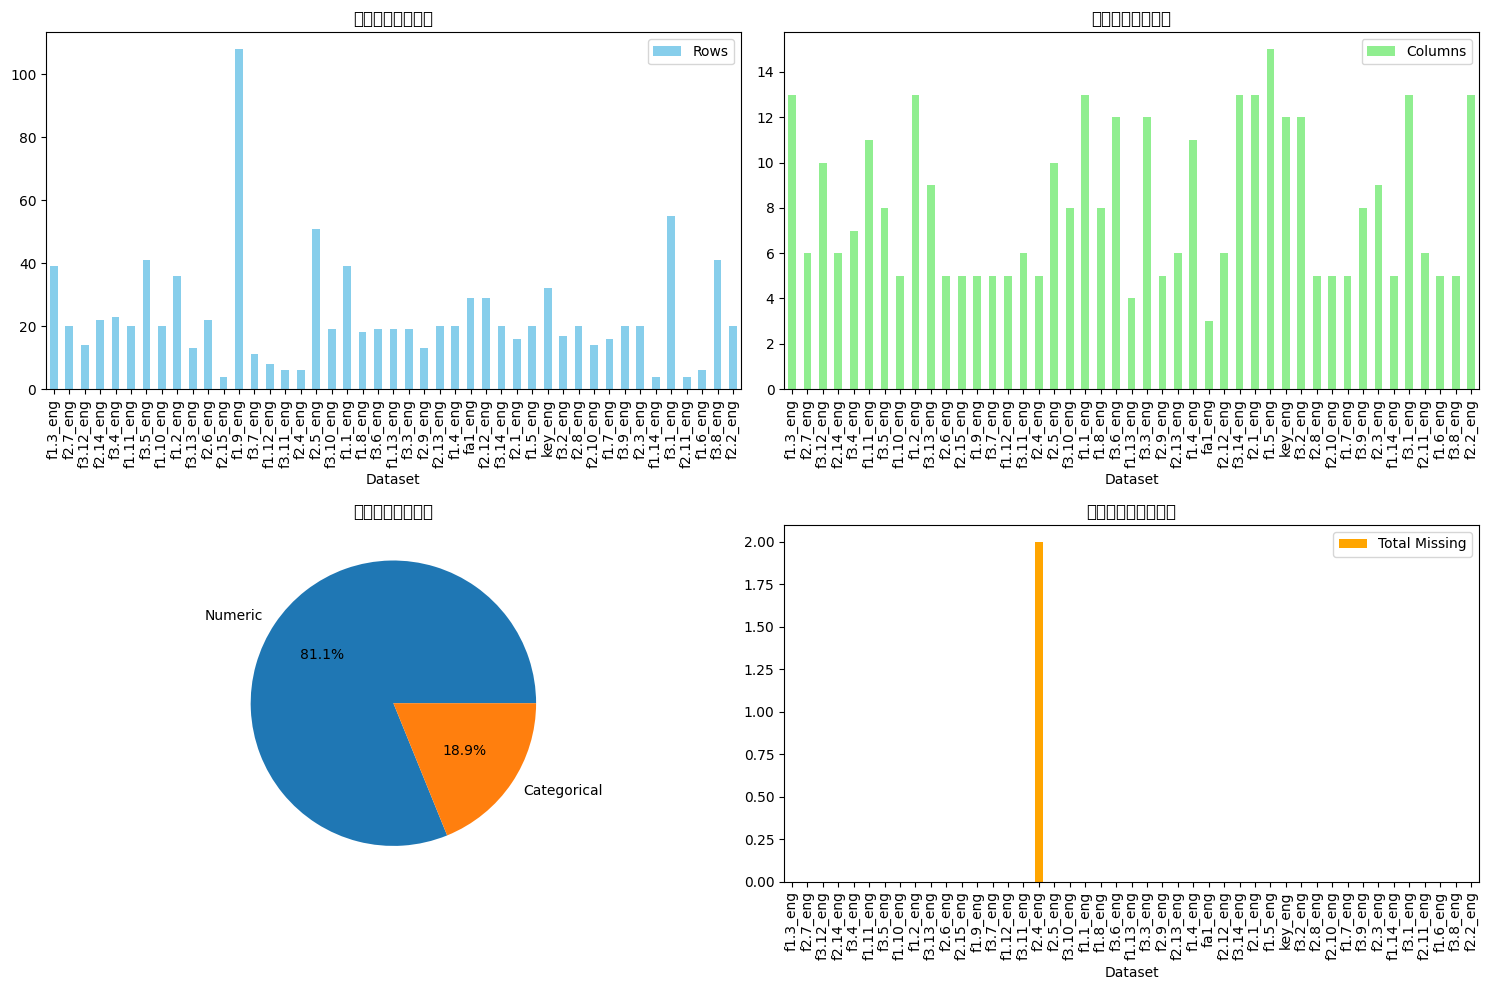

In [12]:
# 单元格 9: 创建数据概览函数
def create_data_overview(cleaner):
    """创建数据概览"""
    display(Markdown("## 📈 数据清洗概览"))

    if not cleaner.cleaned_data:
        display(Markdown("**没有可用的清洗后数据**"))
        return

    overview_data = []
    for name, df in cleaner.cleaned_data.items():
        overview_data.append(
            {
                "Dataset": name,
                "Rows": len(df),
                "Columns": len(df.columns),
                "Numeric Columns": len(df.select_dtypes(include=[np.number]).columns),
                "Categorical Columns": len(
                    df.select_dtypes(include=["object"]).columns
                ),
                "Total Missing": df.isnull().sum().sum(),
            }
        )

    overview_df = pd.DataFrame(overview_data)
    display(overview_df)

    # 可视化概览
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 行数对比
    overview_df.plot(
        x="Dataset",
        y="Rows",
        kind="bar",
        ax=axes[0, 0],
        title="各数据集行数对比",
        color="skyblue",
    )

    # 列数对比
    overview_df.plot(
        x="Dataset",
        y="Columns",
        kind="bar",
        ax=axes[0, 1],
        title="各数据集列数对比",
        color="lightgreen",
    )

    # 数据类型分布
    numeric_sum = overview_df["Numeric Columns"].sum()
    categorical_sum = overview_df["Categorical Columns"].sum()
    axes[1, 0].pie(
        [numeric_sum, categorical_sum],
        labels=["Numeric", "Categorical"],
        autopct="%1.1f%%",
    )
    axes[1, 0].set_title("总体数据类型分布")

    # 缺失值总量
    overview_df.plot(
        x="Dataset",
        y="Total Missing",
        kind="bar",
        ax=axes[1, 1],
        title="各数据集缺失值总量",
        color="orange",
    )

    plt.tight_layout()
    plt.show()


# 执行数据概览
create_data_overview(cleaner)